### DATA EXTRACTION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from matplotlib import style

c:\Users\ASUS\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\ASUS\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv (r"loan.csv")
df.shape

C:\Users\ASUS\AppData\Local\Temp\ipykernel_10192\3613808518.py:1: DtypeWarning: Columns (19,47,55,112,123,124,125,128,129,130,133,139,140,141) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv (r"loan.csv")


(2260668, 145)

### **DATA PREPROCESSING**

In [3]:
# DROP COLUMNS HAVING MISSING VALUE RATIO > 0.95
for x in df.columns:
    if (df[x].isnull().sum()/df['loan_amnt'].count()) > 0.95:
        df.drop(columns = x, inplace = True)

In [114]:
df.shape

(2260668, 111)

In [115]:
df.describe()

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
count,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260664e+06,2.258957e+06,2.260639e+06,2.260638e+06,1.102166e+06,...,2.190392e+06,2.190392e+06,2.190237e+06,2.185289e+06,2.259303e+06,2.260563e+06,2.190392e+06,2.210638e+06,2.210638e+06,2.190392e+06
mean,1.504693e+04,1.504166e+04,1.502344e+04,1.309291e+01,4.458076e+02,7.799243e+04,1.882420e+01,3.068792e-01,5.768354e-01,3.454092e+01,...,8.293767e-02,2.076755e+00,9.411458e+01,4.243513e+01,1.281935e-01,4.677109e-02,1.782428e+05,5.102294e+04,2.319377e+04,4.373201e+04
std,9.190245e+03,9.188413e+03,9.192332e+03,4.832114e+00,2.671737e+02,1.126962e+05,1.418333e+01,8.672303e-01,8.859632e-01,2.190047e+01,...,4.935732e-01,1.830711e+00,9.036140e+00,3.621616e+01,3.646130e-01,3.775338e-01,1.815748e+05,4.991124e+04,2.300656e+04,4.507298e+04
min,5.000000e+02,5.000000e+02,0.000000e+00,5.310000e+00,4.930000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.000000e+03,8.000000e+03,8.000000e+03,9.490000e+00,2.516500e+02,4.600000e+04,1.189000e+01,0.000000e+00,0.000000e+00,1.600000e+01,...,0.000000e+00,1.000000e+00,9.130000e+01,0.000000e+00,0.000000e+00,0.000000e+00,5.073100e+04,2.089200e+04,8.300000e+03,1.500000e+04
50%,1.290000e+04,1.287500e+04,1.280000e+04,1.262000e+01,3.779900e+02,6.500000e+04,1.784000e+01,0.000000e+00,0.000000e+00,3.100000e+01,...,0.000000e+00,2.000000e+00,1.000000e+02,3.750000e+01,0.000000e+00,0.000000e+00,1.142985e+05,3.786400e+04,1.630000e+04,3.269600e+04
75%,2.000000e+04,2.000000e+04,2.000000e+04,1.599000e+01,5.933200e+02,9.300000e+04,2.449000e+01,0.000000e+00,1.000000e+00,5.000000e+01,...,0.000000e+00,3.000000e+00,1.000000e+02,7.140000e+01,0.000000e+00,0.000000e+00,2.577550e+05,6.435000e+04,3.030000e+04,5.880425e+04
max,4.000000e+04,4.000000e+04,4.000000e+04,3.099000e+01,1.719830e+03,1.100000e+08,9.990000e+02,5.800000e+01,3.300000e+01,2.260000e+02,...,5.800000e+01,3.200000e+01,1.000000e+02,1.000000e+02,1.200000e+01,8.500000e+01,9.999999e+06,3.408095e+06,1.569000e+06,2.118996e+06


### **Discorvering data**

#### ***FUNDED BY PLATFORM***

Some loans are funded not only by the lenders, but also by the platform itself

In [116]:
# loan_amnt, funded_amnt, funded_amnt_inv
df[['loan_amnt','funded_amnt','funded_amnt_inv']].describe()

,loan_amnt,funded_amnt,funded_amnt_inv
count,2.260668e+06,2.260668e+06,2.260668e+06
mean,1.504693e+04,1.504166e+04,1.502344e+04
std,9.190245e+03,9.188413e+03,9.192332e+03
min,5.000000e+02,5.000000e+02,0.000000e+00
25%,8.000000e+03,8.000000e+03,8.000000e+03
50%,1.290000e+04,1.287500e+04,1.280000e+04
75%,2.000000e+04,2.000000e+04,2.000000e+04
max,4.000000e+04,4.000000e+04,4.000000e+04


In [117]:
# the total amount funded by platform
funded_by_plt = (df['funded_amnt'] - df['funded_amnt_inv']).sum()
print ('the funded amount by platform: ', funded_by_plt)

the funded amount by platform:  41203914.19383874


In [118]:
# funded by platform ratio
fbpr = df[(df['funded_amnt'] - df['funded_amnt_inv']) != 0].shape[0]/df['loan_amnt'].count()
fbpr

0.06684395939607231

The ratio at which the funded amount by platform (not only via investors) is 6.68%. We will create a new col called 'funded_plt' with values 1-0 (funded by platform/ not funded by platform) as loans which are funded by platform may have lower risk as they might pass some of the platforms' criteria

In [119]:
df['funded_plt_ratio'] = (df['funded_amnt'] - df['funded_amnt_inv'])/ df['funded_amnt']
df['funded_plt'] = df['funded_plt_ratio'].apply(lambda x: 1 if x>0 else 0)

#### ***Employment title and employment length***

In [10]:
# value counts of data that has both emp_title and emp_length null
test_emp = df[df['emp_title'].isnull()]
test_emp = test_emp[test_emp['emp_length'].isnull()]
test_emp['loan_status'].value_counts() 
#check loan_status (y variable) for accounts that have null value for both

loan_status
Current                                                68268
Fully Paid                                             54633
Charged Off                                            20248
Late (31-120 days)                                      1925
In Grace Period                                          572
Late (16-30 days)                                        427
Does not meet the credit policy. Status:Fully Paid        18
Does not meet the credit policy. Status:Charged Off       15
Default                                                    3
Name: count, dtype: int64

In [11]:
# empployment title (null check)
df['emp_title'].isnull().sum()/ df['emp_title'].count()
test_emp['loan_status'].count()/ df['emp_title'].count()

0.06978510282519121

- there is a huge amount of null (~8%) in employment title
- also a huge amount of missing information (~7%) in both employment title and employment length

As the null percentages are high + the fact that loan status figure of accounts that don't have information for employment title and employment lenght seems meaningful for futher exploration, I don't drop null values

In [12]:
#### Description column

#### ***Delienq_2yrs columns***

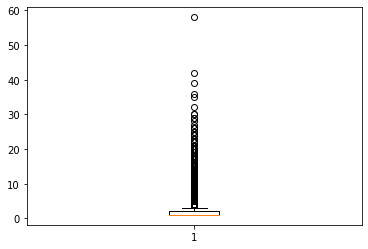

In [13]:
df[['issue_d','delinq_2yrs']]
plot1 = df[df['delinq_2yrs'] > 0]['delinq_2yrs'] 
# extract loans that have delinq_2yrs not 0 as it domintates the data
plt.boxplot(plot1) 
plt.show()

In [14]:
test = df[df['delinq_2yrs'] > 0] #drop value 0 as it dominates the data, therefore finding threshold doesn't mean much
# use threshold in boxplot to normalize data
Q1 = test['delinq_2yrs'].quantile(0.25)
Q3 = test['delinq_2yrs'].quantile(0.75)
IQR = Q3-Q1
IQR
upper_threshold = Q3 + 1.5 * IQR

# upper_threshold = 3.5

In [15]:
bins = [0,1,upper_threshold,60]
# bins edge (0 - 1) means that delinq_2yrs = 0 will go into this
name = ['none', 'low','high']
df['delinq_2yrs'] = pd.cut(df['delinq_2yrs'], bins = bins, labels = name, right = False)

In [16]:
df['delinq_2yrs']

0          none
1          none
2          none
3          none
4          none
           ... 
2260663    none
2260664     low
2260665    none
2260666     low
2260667    none
Name: delinq_2yrs, Length: 2260668, dtype: category
Categories (3, object): ['none' < 'low' < 'high']

#### ***earliest_cr_line***

In [4]:
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3660\2066518133.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])


In [5]:
# new col to show credit_history of that loan
df['credit_history'] = round(pd.to_numeric((pd.to_datetime('2021-12-01') - df['earliest_cr_line']).dt.days/30))

In [19]:
df['credit_history'].describe()

count    2.260639e+06
mean     2.675555e+02
std      9.553684e+01
min      7.400000e+01
25%      2.020000e+02
50%      2.520000e+02
75%      3.180000e+02
max      1.081000e+03
Name: credit_history, dtype: float64

In [6]:
df.drop(columns = 'earliest_cr_line', inplace = True)

#### ***Missing values handling with columns having small null ratio***

In [7]:
df['mths_since_last_delinq'].fillna(0,inplace = True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3660\1754342388.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['mths_since_last_delinq'].fillna(0,inplace = True)


In [8]:
df['mths_since_last_record'].fillna(0,inplace = True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3660\2235725753.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['mths_since_last_record'].fillna(0,inplace = True)


#### ***emp_length_int***

In [9]:
df['emp_length_int'] = df['emp_length'].str.replace('\+ years', '') # replace + years with empty string
df['emp_length_int'] = df['emp_length_int'].str.replace('< 1 year', str(0)) # replace <1 year with 0 as a string
df['emp_length_int'] = df['emp_length_int'].str.replace('n/a',  str(0)) # replace n/a with 0 as a string
df['emp_length_int'] = df['emp_length_int'].str.replace(' years', '')  # replace with empty string
df['emp_length_int'] = df['emp_length_int'].str.replace(' year', '') # replae with empty string
df['emp_length_int'] = df['emp_length_int'].str.replace('10+ years', '') # replace + years with empty string
df['emp_length_int'] = df['emp_length_int'].str.replace('+', '') # replace + years with empty string
# convert to int



In [10]:
df['term_int'] = df['term'].str.replace(' months', '')
df['term_int'] = pd.to_numeric(df['term_int'])

In [11]:
df.drop(columns = 'emp_length', inplace = True)

In [12]:
df['emp_length_int'].fillna(0,inplace = True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3660\3926589220.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['emp_length_int'].fillna(0,inplace = True)


#### ***ISSUE_D***

In [27]:
df['issue_d']

0          Dec-2018
1          Dec-2018
2          Dec-2018
3          Dec-2018
4          Dec-2018
             ...   
2260663    Oct-2017
2260664    Oct-2017
2260665    Oct-2017
2260666    Oct-2017
2260667    Oct-2017
Name: issue_d, Length: 2260668, dtype: object

In [13]:
# Check how many months since the loans were issued
df['issue_d_date'] = pd.to_datetime(df['issue_d'])
df['mths_since_issue_d'] = round(pd.to_numeric((pd.to_datetime('2021-12-01') - df['issue_d_date']).dt.days/30))
# pick 2021-12-01 is the time now for the dataset

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3660\2988305333.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['issue_d_date'] = pd.to_datetime(df['issue_d'])


In [14]:
# df.drop(columns = ['issue_d_date'], inplace = True)
df['mths_since_issue_d'].describe()

count    2.260668e+06
mean     6.802051e+01
std      2.176196e+01
min      3.700000e+01
25%      5.000000e+01
50%      6.600000e+01
75%      8.100000e+01
max      1.770000e+02
Name: mths_since_issue_d, dtype: float64

In [30]:
pd.options.display.max_columns = None

In [22]:
df.head(3)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,funded_plt_ratio,funded_plt,credit_history,emp_length_int,term_int,issue_d_date,mths_since_issue_d
0,2500,2500,2500.0,36 months,13.56,84.92,C,C1,Chef,10+ years,RENT,55000.0,Not Verified,Dec-2018,Current,n,NaN,debt_consolidation,Debt consolidation,109xx,NY,18.24,very low,2001-04-01,1.0,0.0,45.0,9.0,1.0,4341,10.3,34.0,w,2386.02,2386.02,167.02,167.02,113.98,53.04,0.0,0.0,0.0,Feb-2019,84.92,Mar-2019,Feb-2019,0.0,NaN,1,Individual,NaN,NaN,NaN,0.0,0.0,16901.0,2.0,2.0,1.0,2.0,2.0,12560.0,69.0,2.0,7.0,2137.0,28.0,42000.0,1.0,11.0,2.0,9.0,1878.0,34360.0,5.9,0.0,0.0,140.0,212.0,1.0,1.0,0.0,1.0,NaN,2.0,NaN,0.0,2.0,5.0,3.0,3.0,16.0,7.0,18.0,5.0,9.0,0.0,0.0,0.0,3.0,100.0,0.0,1.0,0.0,60124.0,16901.0,36500.0,18124.0,N,Cash,N,0.0,0,252.0,10,36,2018-12-01,37.0
1,30000,30000,30000.0,60 months,18.94,777.23,D,D2,Postmaster,10+ years,MORTGAGE,90000.0,Source Verified,Dec-2018,Current,n,NaN,debt_consolidation,Debt consolidation,713xx,LA,26.52,very low,1987-06-01,0.0,71.0,75.0,13.0,1.0,12315,24.2,44.0,w,29387.75,29387.75,1507.11,1507.11,612.25,894.86,0.0,0.0,0.0,Feb-2019,777.23,Mar-2019,Feb-2019,0.0,NaN,1,Individual,NaN,NaN,NaN,0.0,1208.0,321915.0,4.0,4.0,2.0,3.0,3.0,87153.0,88.0,4.0,5.0,998.0,57.0,50800.0,2.0,15.0,2.0,10.0,24763.0,13761.0,8.3,0.0,0.0,163.0,378.0,4.0,3.0,3.0,4.0,NaN,4.0,NaN,0.0,2.0,4.0,4.0,9.0,27.0,8.0,14.0,4.0,13.0,0.0,0.0,0.0,6.0,95.0,0.0,1.0,0.0,372872.0,99468.0,15000.0,94072.0,N,Cash,N,0.0,0,420.0,10,60,2018-12-01,37.0
2,5000,5000,5000.0,36 months,17.97,180.69,D,D1,Administrative,6 years,MORTGAGE,59280.0,Source Verified,Dec-2018,Current,n,NaN,debt_consolidation,Debt consolidation,490xx,MI,10.51,very low,2011-04-01,0.0,0.0,0.0,8.0,0.0,4599,19.1,13.0,w,4787.21,4787.21,353.89,353.89,212.79,141.10,0.0,0.0,0.0,Feb-2019,180.69,Mar-2019,Feb-2019,0.0,NaN,1,Individual,NaN,NaN,NaN,0.0,0.0,110299.0,0.0,1.0,0.0,2.0,14.0,7150.0,72.0,0.0,2.0,0.0,35.0,24100.0,1.0,5.0,0.0,4.0,18383.0,13800.0,0.0,0.0,0.0,87.0,92.0,15.0,14.0,2.0,77.0,NaN,14.0,NaN,0.0,0.0,3.0,3.0,3.0,4.0,6.0,7.0,3.0,8.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,136927.0,11749.0,13800.0,10000.0,N,Cash,N,0.0,0,130.0,6,36,2018-12-01,37.0


### NUMERIC DATA

In [15]:
numeric_df = df.select_dtypes(include = ['number'])

In [16]:
numeric_col = numeric_df.columns 

In [17]:
# drop nan value in col that has null ratio small < 0.01%
df.dropna(subset = ['dti','revol_util','collections_12_mths_ex_med','chargeoff_within_12_mths','pub_rec_bankruptcies'],inplace= True)

In [34]:
df[numeric_col]

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,annual_inc_joint,dti_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,funded_plt_ratio,funded_plt,credit_history,term_int,mths_since_issue_d
0,2500,2500,2500.0,13.56,84.92,55000.0,18.24,1.0,0.0,45.0,9.0,1.0,4341,10.3,34.0,2386.02,2386.02,167.020000,167.02,113.98,53.04,0.0,0.0,0.0,84.92,0.0,NaN,1,NaN,NaN,0.0,0.0,16901.0,2.0,2.0,1.0,2.0,2.0,12560.0,69.0,2.0,7.0,2137.0,28.0,42000.0,1.0,11.0,2.0,9.0,1878.0,34360.0,5.9,0.0,0.0,140.0,212.0,1.0,1.0,0.0,1.0,NaN,2.0,NaN,0.0,2.0,5.0,3.0,3.0,16.0,7.0,18.0,5.0,9.0,0.0,0.0,0.0,3.0,100.0,0.0,1.0,0.0,60124.0,16901.0,36500.0,18124.0,0.0,0,252.0,36,37.0
1,30000,30000,30000.0,18.94,777.23,90000.0,26.52,0.0,71.0,75.0,13.0,1.0,12315,24.2,44.0,29387.75,29387.75,1507.110000,1507.11,612.25,894.86,0.0,0.0,0.0,777.23,0.0,NaN,1,NaN,NaN,0.0,1208.0,321915.0,4.0,4.0,2.0,3.0,3.0,87153.0,88.0,4.0,5.0,998.0,57.0,50800.0,2.0,15.0,2.0,10.0,24763.0,13761.0,8.3,0.0,0.0,163.0,378.0,4.0,3.0,3.0,4.0,NaN,4.0,NaN,0.0,2.0,4.0,4.0,9.0,27.0,8.0,14.0,4.0,13.0,0.0,0.0,0.0,6.0,95.0,0.0,1.0,0.0,372872.0,99468.0,15000.0,94072.0,0.0,0,420.0,60,37.0
2,5000,5000,5000.0,17.97,180.69,59280.0,10.51,0.0,0.0,0.0,8.0,0.0,4599,19.1,13.0,4787.21,4787.21,353.890000,353.89,212.79,141.10,0.0,0.0,0.0,180.69,0.0,NaN,1,NaN,NaN,0.0,0.0,110299.0,0.0,1.0,0.0,2.0,14.0,7150.0,72.0,0.0,2.0,0.0,35.0,24100.0,1.0,5.0,0.0,4.0,18383.0,13800.0,0.0,0.0,0.0,87.0,92.0,15.0,14.0,2.0,77.0,NaN,14.0,NaN,0.0,0.0,3.0,3.0,3.0,4.0,6.0,7.0,3.0,8.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,136927.0,11749.0,13800.0,10000.0,0.0,0,130.0,36,37.0
3,4000,4000,4000.0,18.94,146.51,92000.0,16.74,0.0,0.0,0.0,10.0,0.0,5468,78.1,13.0,3831.93,3831.93,286.710000,286.71,168.07,118.64,0.0,0.0,0.0,146.51,0.0,NaN,1,NaN,NaN,0.0,686.0,305049.0,1.0,5.0,3.0,5.0,5.0,30683.0,68.0,0.0,0.0,3761.0,70.0,7000.0,2.0,4.0,3.0,5.0,30505.0,1239.0,75.2,0.0,0.0,62.0,154.0,64.0,5.0,3.0,64.0,NaN,5.0,NaN,0.0,1.0,2.0,1.0,2.0,7.0,2.0,3.0,2.0,10.0,0.0,0.0,0.0,3.0,100.0,100.0,0.0,0.0,385183.0,36151.0,5000.0,44984.0,0.0,0,193.0,36,37.0
4,30000,30000,30000.0,16.14,731.78,57250.0,26.35,0.0,0.0,0.0,12.0,0.0,829,3.6,26.0,29339.02,29339.02,1423.210000,1423.21,660.98,762.23,0.0,0.0,0.0,731.78,0.0,NaN,1,NaN,NaN,0.0,0.0,116007.0,3.0,5.0,3.0,5.0,4.0,28845.0,89.0,2.0,4.0,516.0,54.0,23100.0,1.0,0.0,0.0,9.0,9667.0,8471.0,8.9,0.0,0.0,53.0,216.0,2.0,2.0,2.0,2.0,NaN,13.0,NaN,0.0,2.0,2.0,3.0,8.0,9.0,6.0,15.0,2.0,12.0,0.0,0.0,0.0,5.0,92.3,0.0,0.0,0.0,157548.0,29674.0,9300.0,32332.0,0.0,0,256.0,60,37.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [18]:
# value in col that has null ratio small < 50%
for x in df[numeric_col].columns:
    ratio = df[x].isnull().sum() / df['loan_amnt'].count()
    if ratio <0.5 and ratio >0:
        df[x].fillna (df[x].mean(), inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3660\1175611564.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[x].fillna (df[x].mean(), inplace=True)


In [19]:
df.drop(columns = ['annual_inc_joint','dti_joint'], inplace= True)

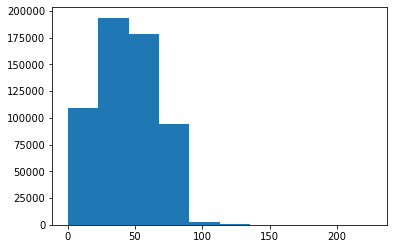

In [37]:
plt.hist(df['mths_since_last_major_derog'],bins=10)
plt.show()

#### ***DATE COL PROCESSING***

In [ ]:
df['mths_since_last_major_derog'].fillna(0.05,inplace = True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3660\813220796.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['mths_since_last_major_derog'].fillna(0.05,inplace = True)


In [39]:
# Create bins based on the distribution of data
bins = [0,0.1,50,100,200]
name = ['none','low', 'high','very high']
df['mths_since_last_major_derog'] = pd.cut(df['mths_since_last_major_derog'], bins = bins, labels = name, right = False)

In [40]:
df['mths_since_last_major_derog'].value_counts()

mths_since_last_major_derog
none         1676262
low           338401
high          238939
very high       2217
Name: count, dtype: int64

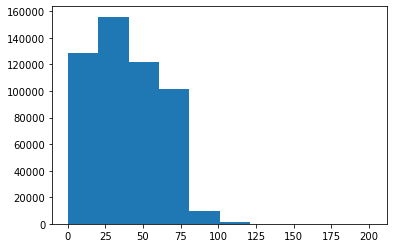

In [41]:
plt.hist(df['mths_since_recent_bc_dlq'],bins=10)
plt.show()

In [42]:
# create bins as distribution of data
# fill 0.05 as we will classify it as group between 0 and 0.1
df['mths_since_recent_bc_dlq'].fillna(0.05,inplace = True)
bins = [0,0.1,50,200]
name = ['none','low', 'high']
df['mths_since_recent_bc_dlq'] = pd.cut(df['mths_since_recent_bc_dlq'], bins = bins, labels = name, right = False)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12024\1723458879.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['mths_since_recent_bc_dlq'].fillna(0.05,inplace = True)


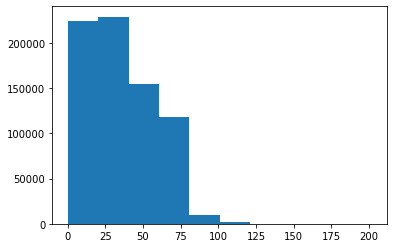

In [43]:
plt.hist(df['mths_since_recent_revol_delinq'],bins=10)
plt.show()

In [44]:
df['mths_since_recent_revol_delinq'].fillna(0.05,inplace = True)
bins = [0,0.1,37,200]
name = ['none','low', 'high']
df['mths_since_recent_revol_delinq'] = pd.cut(df['mths_since_recent_revol_delinq'], bins = bins, labels = name, right = False)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12024\2365176230.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['mths_since_recent_revol_delinq'].fillna(0.05,inplace = True)


In [45]:
df.shape

(2255821, 114)

#### DATE COL DATA PROCESSING

In [21]:
df['next_pymnt_d'] = np.where(
    pd.notnull(df['next_pymnt_d']),  
    0,
    np.where(df['loan_status'] == 'Fully Paid', 1, -1))

In [22]:
df['last_pymnt_d'] = np.where(
    pd.notnull(df['last_pymnt_d']), 
    1, 0
)

For these two columns, we tried to find out  why some of values in these columns null.
- Next_pymnt_d: map the value that if it's not null -> set 0 as the loans still going. Values are null, then set 1 if loan_status is 'fully paid', otherwise it was already default
- Same for last_pymnt_df

#### ***Handling some error***

In [23]:
df['last_pymnt_d'] = df['last_pymnt_d'].map(lambda x: int(x))
df['emp_length_int'] = df['emp_length_int'].map(lambda x: int(x))
df['next_pymnt_d'] = df['next_pymnt_d'].map(lambda x: int(x))

In [24]:
df.drop(columns = ['last_credit_pull_d','term','desc','zip_code','verification_status_joint'], inplace = True)

In [ ]:
# df.to_pickle('preprocessed.pkl')

In [50]:
# numeric_df = df.select_dtypes(include = ['number'])

### GET DUMMY

In [27]:
category_df = df.select_dtypes(include = ['object'])

In [65]:
# category_df.drop(columns = ['desc','zip_code','addr_state','term'],inplace =True)


In [66]:
# category_df.drop(columns = 'emp_title',inplace =True)
# category_df.drop(columns = 'verification_status_joint',inplace =True)

In [67]:
# category_df.drop(columns = ['last_credit_pull_d'], inplace = True)

In [68]:
# convert next payment date
# category_df['next_pymnt_d'] = np.where(
#     pd.notnull(category_df['next_pymnt_d']),  # Condition 1: If not null, set to 0
#     0,
#     np.where(category_df['loan_status'] == 'Fully Paid', 1, -1)  # Nested condition
# )

In [69]:
# convert last payment date
# category_df['last_pymnt_d'] = np.where(
#     pd.notnull(category_df['last_pymnt_d']),  # Condition 1: If not null, set to 0
#     1, 0
# )

In [91]:
# category_df['last_pymnt_d'].groupby([category_df['last_pymnt_d'],category_df['loan_status']]).count()


last_pymnt_d  loan_status                                        
0             Charged Off                                               2246
              Default                                                      1
              Does not meet the credit policy. Status:Charged Off         10
              Late (31-120 days)                                         153
1             Charged Off                                             259060
              Current                                                 917435
              Default                                                     30
              Does not meet the credit policy. Status:Charged Off        534
              Does not meet the credit policy. Status:Fully Paid        1526
              Fully Paid                                             1040480
              In Grace Period                                           8942
              Late (16-30 days)                                         3719
          

In [28]:
category_df.drop(columns = 'issue_d', inplace = True)
# already process this column above

In [29]:
category_df.columns.values

array(['grade', 'sub_grade', 'emp_title', 'home_ownership',
       'verification_status', 'loan_status', 'pymnt_plan', 'purpose',
       'title', 'addr_state', 'initial_list_status', 'application_type',
       'hardship_flag', 'disbursement_method', 'debt_settlement_flag'],
      dtype=object)

diescrete variable:
- grade, subgrade, home_ownership, verification_status, loan_status, pyment_plan, purpose, initial_list_status, application_type, hardship_flag, disbursement_method, debt_settlement_flag, addr_state: one-hot

not process:
- empt_title, title: label encoder

In [30]:
# One-hot for those col
loan_data_dummies = [pd.get_dummies(category_df['grade'], prefix = 'grade', prefix_sep = ':',dtype='int'),
                     pd.get_dummies(category_df['sub_grade'], prefix = 'sub_grade', prefix_sep = ':',dtype='int'),
                     pd.get_dummies(category_df['home_ownership'], prefix = 'home_ownership', prefix_sep = ':',dtype='int'),
                     pd.get_dummies(category_df['verification_status'], prefix = 'verification_status', prefix_sep = ':',dtype='int'),
                     pd.get_dummies(category_df['loan_status'], prefix = 'loan_status', prefix_sep = ':',dtype='int'),
                     pd.get_dummies(category_df['purpose'], prefix = 'purpose', prefix_sep = ':',dtype='int'),
                     pd.get_dummies(category_df['addr_state'], prefix = 'addr_state', prefix_sep = ':',dtype='int'),
                     pd.get_dummies(category_df['pymnt_plan'], prefix = 'pymnt_plan', prefix_sep = ':',dtype='int'),
                     pd.get_dummies(category_df['initial_list_status'], prefix = 'initial_list_status', prefix_sep = ':',dtype='int'),
                     pd.get_dummies(category_df['application_type'], prefix = 'application_type', prefix_sep = ':',dtype='int'),
                     pd.get_dummies(category_df['hardship_flag'], prefix = 'hardship_flag', prefix_sep = ':',dtype='int'),
                     pd.get_dummies(category_df['debt_settlement_flag'], prefix = 'debt_settlement_flag', prefix_sep = ':',dtype='int'),
                     pd.get_dummies(category_df['disbursement_method'], prefix = 'disbursement_method', prefix_sep = ':',dtype='int'),
                     ]


#next_pymnt_d #mths_since_last_major_derog #funded_plt #last_pymnt_amnt

In [31]:
loan_data_dummies= pd.concat(loan_data_dummies, axis = 1)


In [32]:
loan_data = pd.concat([df, loan_data_dummies], axis = 1)


In [35]:
# loan_data.to_pickle ('preprocessing_v2.pkl')

In [91]:
loan_data.head(2)

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,grade,sub_grade,emp_title,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,purpose,title,addr_state,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,funded_plt_ratio,funded_plt,credit_history,emp_length_int,term_int,issue_d_date,mths_since_issue_d,good_bad,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G,sub_grade:A1,sub_grade:A2,sub_grade:A3,sub_grade:A4,sub_grade:A5,sub_grade:B1,sub_grade:B2,sub_grade:B3,sub_grade:B4,sub_grade:B5,sub_grade:C1,sub_grade:C2,sub_grade:C3,sub_grade:C4,sub_grade:C5,sub_grade:D1,sub_grade:D2,sub_grade:D3,sub_grade:D4,sub_grade:D5,sub_grade:E1,sub_grade:E2,sub_grade:E3,sub_grade:E4,sub_grade:E5,sub_grade:F1,sub_grade:F2,sub_grade:F3,sub_grade:F4,sub_grade:F5,sub_grade:G1,sub_grade:G2,sub_grade:G3,sub_grade:G4,sub_grade:G5,home_ownership:ANY,home_ownership:MORTGAGE,home_ownership:NONE,home_ownership:OTHER,home_ownership:OWN,home_ownership:RENT,verification_status:Not Verified,verification_status:Source Verified,verification_status:Verified,loan_status:Charged Off,loan_status:Current,loan_status:Default,loan_status:Does not meet the credit policy. Status:Charged Off,loan_status:Does not meet the credit policy. Status:Fully Paid,loan_status:Fully Paid,loan_status:In Grace Period,loan_status:Late (16-30 days),loan_status:Late (31-120 days),purpose:car,purpose:credit_card,purpose:debt_consolidation,purpose:educational,purpose:home_improvement,purpose:house,purpose:major_purchase,purpose:medical,purpose:moving,purpose:other,purpose:renewable_energy,purpose:small_business,purpose:vacation,purpose:wedding,addr_state:AK,addr_state:AL,addr_state:AR,addr_state:AZ,addr_state:CA,addr_state:CO,addr_state:CT,addr_state:DC,addr_state:DE,addr_state:FL,addr_state:GA,addr_state:HI,addr_state:IA,addr_state:ID,addr_state:IL,addr_state:IN,addr_state:KS,addr_state:KY,addr_state:LA,addr_state:MA,addr_state:MD,addr_state:ME,addr_state:MI,addr_state:MN,addr_state:MO,addr_state:MS,addr_state:MT,addr_state:NC,addr_state:ND,addr_state:NE,addr_state:NH,addr_state:NJ,addr_state:NM,addr_state:NV,addr_state:NY,addr_state:OH,addr_state:OK,addr_state:OR,addr_state:PA,addr_state:RI,addr_state:SC,addr_state:SD,addr_state:TN,addr_state:TX,addr_state:UT,addr_state:VA,addr_state:VT,addr_state:WA,addr_state:WI,addr_state:WV,addr_state:WY,pymnt_plan:n,pymnt_plan:y,initial_list_status:f,initial_list_status:w,application_type:Individual,application_type:Joint App,hardship_flag:N,hardship_flag:Y,debt_settlement_flag:N,debt_settlement_flag:Y,disbursement_method:Cash,disbursement_method:DirectPay
0,2500,2500,2500.0,13.56,84.92,C,C1,Chef,RENT,55000.0,Not Verified,Dec-2018,Current,n,debt_consolidation,Debt consolidat

In [34]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder() #these two columns have two many unique data => one hot will make data heavy
loan_data['emp_title'] = loan_data['emp_title'].map(lambda x: str(x))
loan_data['emp_title'] = encoder.fit_transform(loan_data['emp_title'])

loan_data['title'] = loan_data['title'].map(lambda x: str(x))
loan_data['title'] = encoder.fit_transform(loan_data['title'])

In [11]:
len(df['emp_title'].unique())

512695

In [74]:
# category_df['grade'] = encoder.fit_transform(category_df['grade'])

In [75]:
# category_df

,grade,sub_grade,home_ownership,verification_status,loan_status,pymnt_plan,purpose,title,initial_list_status,application_type,hardship_flag,disbursement_method,debt_settlement_flag
0,2,10,5,0,1,0,2,16419,1,0,0,0,0
1,3,16,1,1,1,0,2,16419,1,0,0,0,0
2,3,15,1,1,1,0,2,16419,1,0,0,0,0
3,3,16,1,1,1,0,2,16419,1,0,0,0,0
4,2,13,1,0,1,0,2,16419,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260663,2,12,1,0,1,0,2,16419,1,0,0,0,0
2260664,4,23,1,0,5,0,2,16419,1,1,0,0,0
2260665,1,9,4,1,1,0,2,16419,1,0,0,0,0
2260666,3,19,5,0,1,0,2,16419,1,0,0,0,0


In [76]:
# loan_df = pd.concat([numeric_df, category_df], axis = 1)

In [77]:
# loan_df.shape

(2255821, 102)

In [123]:
# loan_df['loan_status'].value_counts()

loan_status
5    1040480
1     917435
0     261306
8      21838
6       8942
7       3719
4       1526
3        544
2         31
Name: count, dtype: int64

In [78]:
# loan_df['good_bad'] = np.where(loan_df['loan_status'].isin(['Charged Off', 'Default',
#                                                        'Does not meet the credit policy. Status:Charged Off',
#                                                        'Late (31-120 days)']), 0, 1)

In [124]:
# df['good_bad'].value_counts()

good_bad
1    1972102
0     283719
Name: count, dtype: int64

In [80]:
# df = pd.concat([numeric_df, category_df], axis = 1)

- Drop purpose col as it's alraedy classified in title col
- Drop zip_code

In [108]:
loan_data['good_bad'] = np.where(loan_data['loan_status'].isin(['Charged Off', 'Default',
                                                       'Does not meet the credit policy. Status:Charged Off',
                                                       'Late (31-120 days)']), 0, 1)

# PD model




In [113]:
# loan_data.to_pickle('loan_data.to_pickle')

In [5]:
loan_data = pd.read_pickle('loan_data.to_pickle')

In [4]:
loan_data['good_bad'] = loan_data['good_bad'].astype(int)

In [5]:
loan_data['good_bad'].value_counts()

good_bad
1    1972102
0     283719
Name: count, dtype: int64

In [6]:
df_input=loan_data.drop('good_bad', axis = 1) # seperate dataframe containing features (x)
df_output=loan_data['good_bad'] # seperate the target variable

### Applying WOE/IG

In [7]:
# FUNCTION CALCULATING WOE
def woe_discrete(df, discrete_variabe_name, good_bad_variable_df):
    df = pd.concat([df[discrete_variabe_name], good_bad_variable_df], axis = 1)
    df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
                    df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)
    df = df.iloc[:, [0, 1, 3]]
    df.columns = [df.columns.values[0], 'n_obs', 'prop_good']
    df['prop_n_obs'] = df['n_obs'] / df['n_obs'].sum()
    df['n_good'] = df['prop_good'] * df['n_obs']
    df['n_bad'] = (1 - df['prop_good']) * df['n_obs']
    df['prop_n_good'] = df['n_good'] / df['n_good'].sum()
    df['prop_n_bad'] = df['n_bad'] / df['n_bad'].sum()
    df['WoE'] = np.log(df['prop_n_good'] / df['prop_n_bad'])
    #df = df.sort_values(['WoE'])
    #df = df.reset_index(drop = True)
    #df['diff_prop_good'] = df['prop_good'].diff().abs()
    #df['diff_WoE'] = df['WoE'].diff().abs()
    df['IV'] = (df['prop_n_good'] - df['prop_n_bad']) * df['WoE']
    df['IV'] = df['IV'].sum()
    return df

In [21]:
# Plot by WOE
def plot_by_woe(df_WoE, value, rotation_of_x_axis_labels = 0):
    style.use('dark_background') #set some style
    plt.figure(figsize=(18, 6))
    plt.plot(df_WoE[value].values, df_WoE['WoE'].values, "r--", marker = 'o') #plot
    # Set label of x, y, title, xticks
    
    plt.xlabel(value)
    plt.ylabel('Weight of Evidence')
    plt.title(str('Weight of Evidence by ' + df_WoE.columns[0]))
    plt.xticks(rotation = rotation_of_x_axis_labels)
    plt.show()

In [9]:
# df.head(100).to_excel('discrete.xlsx')

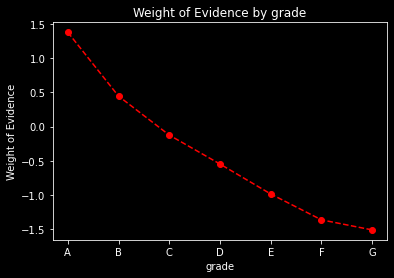

In [10]:
# apply to grade col
pd_grade= woe_discrete(df_input, 'grade', df_output)
plot_by_woe (pd_grade, 'grade')

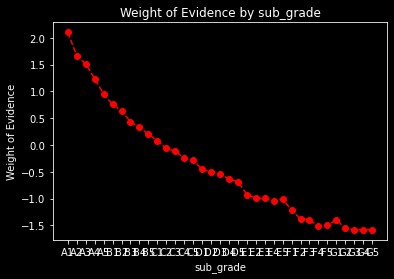

In [11]:
pd_subgrade= woe_discrete(df_input, 'sub_grade', df_output)
plot_by_woe (pd_subgrade, 'sub_grade')

nothing to handle in sub_grade and grade

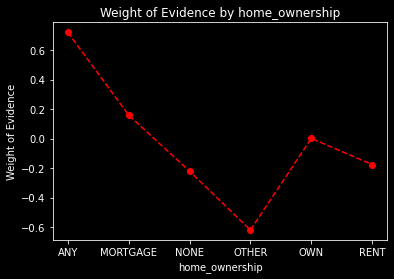

In [12]:
# Home Ownership
pd_homwown = woe_discrete(df_input, 'home_ownership', df_output)
plot_by_woe (pd_homwown, 'home_ownership')

In [13]:
df_input.shape

(2255821, 245)

- End up with 4 categories: OTHER_NONE_ANY, OWN, MARTGAGE, RENT

In [16]:
df_input['home_ownership:OTHER_NONE_ANY'] = sum([df_input['home_ownership:NONE'],
                                                      df_input['home_ownership:OTHER'],df_input['home_ownership:ANY']])


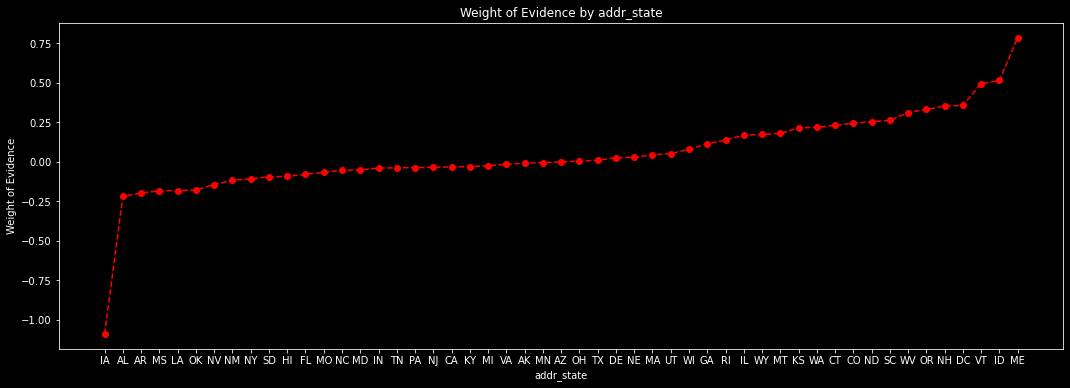

In [22]:
pd_state = woe_discrete(df_input, 'addr_state', df_output)
pd_state.sort_values(by=['WoE'], inplace= True)
plot_by_woe(pd_state, 'addr_state')


WOE good: (-0.125 < WOE <0.125)
- Group 1 (low obs, <10.000)
- Group 2 (medium obs, <100.000)
- Group 3(high obs)

In [45]:
good_WOE = pd_state[(pd_state['WoE']>= -0.125)][(pd_state['WoE'] <= 0.125)]
group1 = good_WOE[good_WOE['n_obs']<10000]
group2 = good_WOE[good_WOE['n_obs']>=10000][good_WOE['n_obs']<=100000]
group3= good_WOE[good_WOE['n_obs']>100000]

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\1425211918.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  good_WOE = pd_state[(pd_state['WoE']>= -0.125)][(pd_state['WoE'] <= 0.125)]
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\1425211918.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group2 = good_WOE[good_WOE['n_obs']>=10000][good_WOE['n_obs']<=100000]


In [ ]:
med_low_WOE = pd_state[(pd_state['WoE'] <-0.125)]
med_low_WOE
group4 = ['AL','AR','MS','LA','OK','NV']
# except IA, all comes in one group

In [75]:
med_high_WOE =  pd_state[(pd_state['WoE'] > 0.125)]
med_high_WOE
group5 = ['DC','VT','ID','ME','IA'] #IA comes here
group6 = ['KS', 'WA', 'CT', 'CO', 'SC', 'OR', 'NH','IL']
group7 = ['ND', 'WV' , 'WY', 'MT', 'RI']
# DC,VT,ID,,ME comes in one group, bad WOE, low n_obs
# KS, WA, CT, CO, SC, OR, NH comes in one group, bad WOE (but similar to each other, good n_obs)
# ND, WV , WY, MT, RI (low n_obs)
# IL comes in group 2 of good one
med_high_WOE

,addr_state,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
39,RI,9994,0.888633,0.004430,8881.0,1113.0,0.004503,0.003923,0.137984,0.014411
14,IL,91030,0.891596,0.040353,81162.0,9868.0,0.041155,0.034781,0.168279,0.014411
50,WY,4735,0.892080,0.002099,4224.0,511.0,0.002142,0.001801,0.173297,0.014411
26,MT,6283,0.892726,0.002785,5609.0,674.0,0.002844,0.002376,0.180027,0.014411
16,KS,19060,0.895960,0.008449,17077.0,1983.0,0.008659,0.006989,0.214251,0.014411
47,WA,46933,0.896363,0.020805,42069.0,4864.0,0.021332,0.017144,0.218579,0.014411
6,CT,35724,0.897436,0.015836,32060.0,3664.0,0.016257,0.012914,0.230183,0.014411
5,CO,48068,0.898852,0.021308,43206.0,4862.0,0.021909,0.017137,0.245659,0.014411
28,ND,3583,0.899526,0.001588,3223.0,360.0,0.001634,0.001269,0.253093,0.014411
40,SC,27941,0.900433,0.012386,25159.0,2782.0,0.012757,0.009805,0.263175,0.014411


In [76]:
df_input['addr_state:group1'] = sum([df_input['addr_state:' + i] for i in group1['addr_state'].values])
df_input['addr_state:group2'] = sum([df_input['addr_state:' + i] for i in group2['addr_state'].values])
df_input['addr_state:group3'] = sum([df_input['addr_state:' + i] for i in group3['addr_state'].values])

df_input['addr_state:group4'] = sum([df_input['addr_state:' + i] for i in group4])
df_input['addr_state:group5'] = sum([df_input['addr_state:' + i] for i in group5])
df_input['addr_state:group6'] = sum([df_input['addr_state:' + i] for i in group6])
df_input['addr_state:group7'] = sum([df_input['addr_state:' + i] for i in group7])


In [77]:
df_input['addr_state:group1'].value_counts()

addr_state:group1
0    2231821
1      24000
Name: count, dtype: int64

purpose


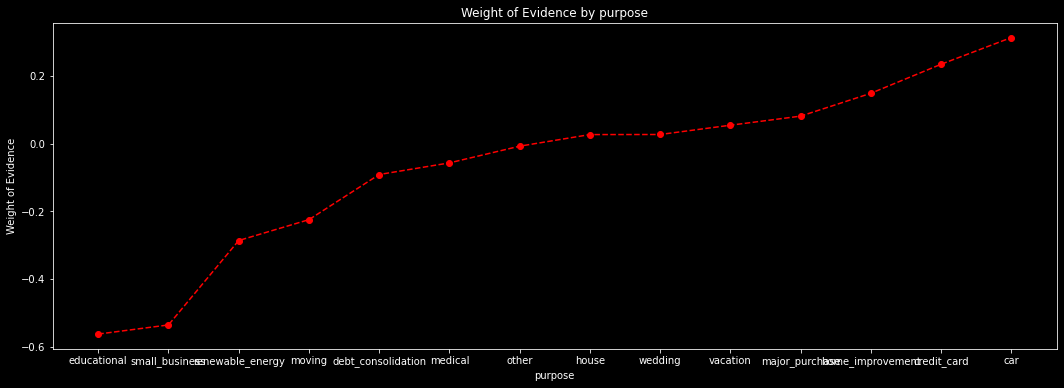

In [81]:
pd_purpose = woe_discrete(df_input, 'purpose', df_output)
pd_purpose.sort_values(by =['WoE'], inplace= True)
plot_by_woe (pd_purpose, 'purpose')

In [82]:
df_input['purpose:edu_smallbusi_wed,renewablener'] = sum([df_input['purpose:educational'], df_input['purpose:small_business'], df_input['purpose:wedding'], df_input['purpose:renewable_energy'],
                                                                 df_input['purpose:moving'], df_input['purpose:house']])
df_input['purpose:oth__med__vacation'] = sum([df_input['purpose:other'], df_input['purpose:medical'], df_input['purpose:vacation']])

df_input['purpose:major_purch__car__home_impr'] = sum([df_input['purpose:major_purchase'], df_input['purpose:car'], df_input['purpose:home_improvement']])

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12024\492685077.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\ASUS\AppData\Local\Temp\ipykernel_12024\492685077.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


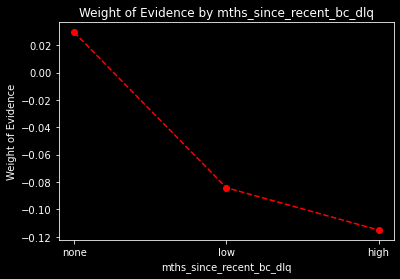

In [67]:
pd_delinq = woe_discrete(df_input, 'mths_since_recent_bc_dlq', df_output)
plot_by_woe (pd_delinq, 'mths_since_recent_bc_dlq')

nothing to process here

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12024\492685077.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\ASUS\AppData\Local\Temp\ipykernel_12024\492685077.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


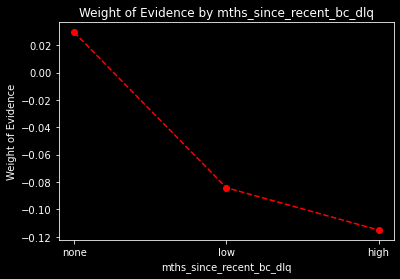

In [68]:
pd_delinq = woe_discrete(df_input, 'mths_since_recent_bc_dlq', df_output)
plot_by_woe (pd_delinq, 'mths_since_recent_bc_dlq')

nothing to process

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\492685077.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\492685077.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


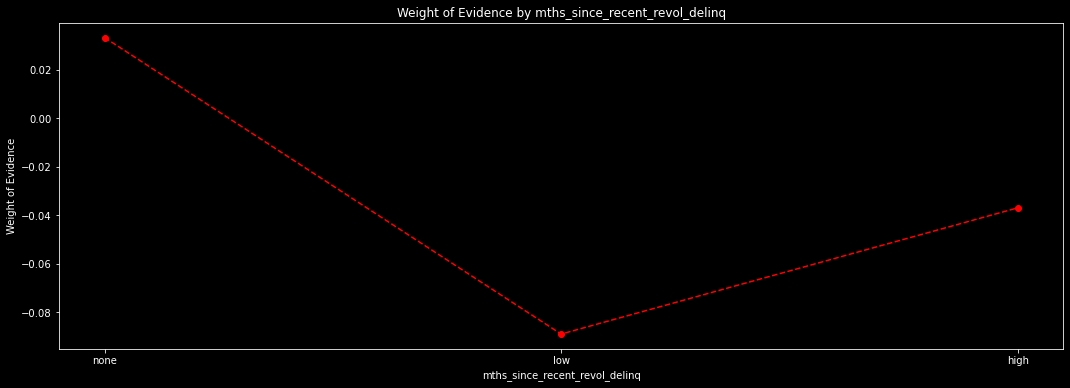

,mths_since_recent_revol_delinq,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,none,1517927,0.877849,0.672894,1332510.0,185417.0,0.675680,0.653526,0.033338,0.002426
1,low,410134,0.864118,0.181811,354404.0,55730.0,0.179709,0.196427,-0.088956,0.002426
2,high,327759,0.870115,0.145295,285188.0,42571.0,0.144611,0.150047,-0.036899,0.002426


In [83]:
pd_delinq = woe_discrete(df_input, 'mths_since_recent_revol_delinq', df_output)
plot_by_woe (pd_delinq, 'mths_since_recent_revol_delinq')
pd_delinq

nothing to process, we decided to leave them seperately

#### ***Continuous features***

In [84]:
def woe_ordered_continuous(df, discrete_variabe_name, good_bad_variable_df):
    df = pd.concat([df[discrete_variabe_name], good_bad_variable_df], axis = 1)
    df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
                    df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)
    df = df.iloc[:, [0, 1, 3]]
    df.columns = [df.columns.values[0], 'n_obs', 'prop_good']
    df['prop_n_obs'] = df['n_obs'] / df['n_obs'].sum()
    df['n_good'] = df['prop_good'] * df['n_obs']
    df['n_bad'] = (1 - df['prop_good']) * df['n_obs']
    df['prop_n_good'] = df['n_good'] / df['n_good'].sum()
    df['prop_n_bad'] = df['n_bad'] / df['n_bad'].sum()
    df['WoE'] = np.log(df['prop_n_good'] / df['prop_n_bad'])
    #df = df.sort_values(['WoE']) # commented out because we want to preserve natural ordering
    #df = df.reset_index(drop = True) # not neededss
    df['diff_prop_good'] = df['prop_good'].diff().abs()
    df['diff_WoE'] = df['WoE'].diff().abs()
    df['IV'] = (df['prop_n_good'] - df['prop_n_bad']) * df['WoE']
    df['IV'] = df['IV'].sum()
    return df

In [87]:
df_input['term_int'].unique()

array([36, 60], dtype=int64)

In [ ]:
# 2 values no need to use the above function
df_input['term:36'] = np.where((df_input['term_int'] == 36), 1, 0)
df_input['term:60'] = np.where((df_input['term_int'] == 60), 1, 0)

emp_length_int

In [91]:
df_input['emp_length_int'].unique()

array([10,  6,  0,  2,  4,  9,  5,  3,  7,  1,  8], dtype=int64)

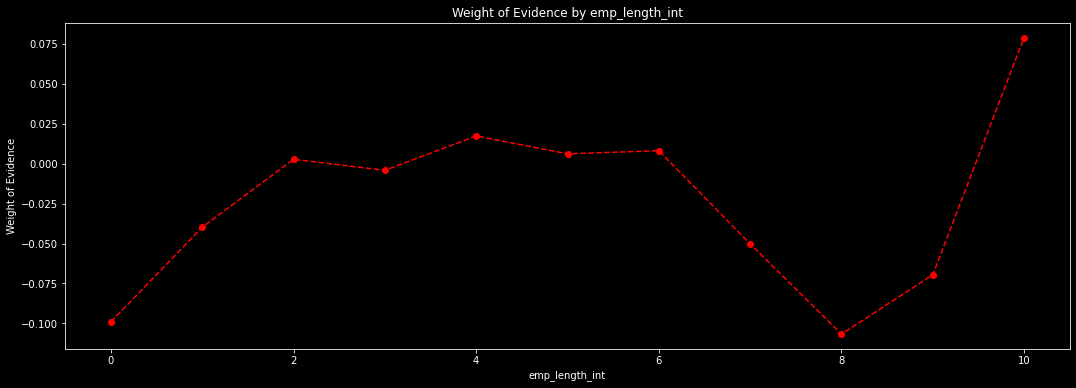

,emp_length_int,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,0,334549,0.862941,0.148305,288696.0,45853.0,0.146390,0.161614,-0.098937,0.004394
1,1,148044,0.869789,0.065628,128767.0,19277.0,0.065294,0.067944,-0.039779,0.004394
2,2,203358,0.874517,0.090148,177840.0,25518.0,0.090178,0.089941,0.002629,0.004394
3,3,180512,0.873759,0.080021,157724.0,22788.0,0.079978,0.080319,-0.004258,0.004394
4,4,136414,0.876112,0.060472,119514.0,16900.0,0.060602,0.059566,0.017249,0.004394
5,5,139536,0.874893,0.061856,122079.0,17457.0,0.061903,0.061529,0.006057,0.004394
6,6,102483,0.875111,0.045430,89684.0,12799.0,0.045476,0.045112,0.008054,0.004394
7,7,92585,0.868596,0.041043,80419.0,12166.0,0.040778,0.042880,-0.050266,0.004394
8,8,91809,0.862029,0.040699,79142.0,12667.0,0.040131,0.044646,-0.106627,0.004394
9,9,79317,0.866372,0.035161,68718.0,10599.0,0.034845,0.037357,-0.069619,0.004394


In [95]:
df_emp_length = woe_discrete(df_input, 'emp_length_int', df_output)
plot_by_woe (df_emp_length, 'emp_length_int')
df_emp_length

In [97]:
df_input['emp_length:0'] = np.where(df_input['emp_length_int'].isin([0]), 1, 0)
df_input['emp_length:1'] = np.where(df_input['emp_length_int'].isin([1]), 1, 0)
df_input['emp_length:2-4'] = np.where(df_input['emp_length_int'].isin(range(2, 5)), 1, 0)
df_input['emp_length:5-6'] = np.where(df_input['emp_length_int'].isin(range(5, 7)), 1, 0)
df_input['emp_length:7-9'] = np.where(df_input['emp_length_int'].isin(range(7, 10)), 1, 0)
df_input['emp_length:10'] = np.where(df_input['emp_length_int'].isin([10]), 1, 0)

mths_since_issue_d

In [101]:
df_input['mths_since_issue_d']

0          37.0
1          37.0
2          37.0
3          37.0
4          37.0
           ... 
2260663    51.0
2260664    51.0
2260665    51.0
2260666    51.0
2260667    51.0
Name: mths_since_issue_d, Length: 2255821, dtype: float64

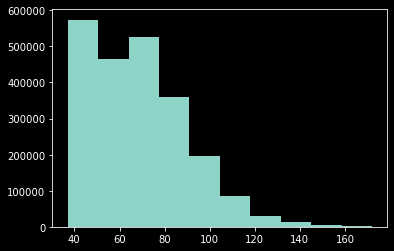

In [100]:
plt.hist(df_input['mths_since_issue_d'])
plt.show()

In [102]:
df_input['mths_since_issue_d_factor'] = pd.cut(
                                        df_input['mths_since_issue_d'], 50)

In [106]:
df_temp = woe_discrete(df_input, 'mths_since_issue_d_factor', df_output)
# plot_by_woe(df_temp,'mths_since_issue_d_factor')
df_temp

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\492685077.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\492685077.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


,mths_since_issue_d_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(36.865, 39.7]",128019,0.995774,0.056751,127478.0,541.0,0.064641,0.001907,3.523409,0.540556
1,"(39.7, 42.4]",127759,0.983657,0.056635,125671.0,2088.0,0.063724,0.007359,2.158590,0.540556
2,"(42.4, 45.1]",130289,0.961862,0.057757,125320.0,4969.0,0.063546,0.017514,1.288781,0.540556
3,"(45.1, 47.8]",71234,0.948227,0.031578,67546.0,3688.0,0.034251,0.012999,0.968854,0.540556
4,"(47.8, 50.5]",116420,0.932254,0.051609,108533.0,7887.0,0.055034,0.027799,0.682967,0.540556
5,"(50.5, 53.2]",121085,0.907007,0.053677,109825.0,11260.0,0.055689,0.039687,0.338761,0.540556
6,"(53.2, 55.9]",77367,0.894050,0.034297,69170.0,8197.0,0.035074,0.028891,0.193928,0.540556
7,"(55.9, 58.6]",104419,0.884485,0.046289,92357.0,12062.0,0.046832,0.042514,0.096731,0.540556
8,"(58.6, 61.3]",95694,0.867191,0.042421,82985.0,12709.0,0.042079,0.044794,-0.062521,0.540556
9,"(61.3, 64.0]",95407,0.854078,0.042294,81485.0,13922.0,0.041319,0.049070,-0.171922,0.540556


In [108]:
df_input['mths_since_issue_d:<38'] = np.where(df_input['mths_since_issue_d'].isin(range(38)), 1, 0)
df_input['mths_since_issue_d:38-39'] = np.where(df_input['mths_since_issue_d'].isin(range(38, 40)), 1, 0)
df_input['mths_since_issue_d:40-41'] = np.where(df_input['mths_since_issue_d'].isin(range(40, 42)), 1, 0)
df_input['mths_since_issue_d:42-48'] = np.where(df_input['mths_since_issue_d'].isin(range(42, 49)), 1, 0)
df_input['mths_since_issue_d:49-52'] = np.where(df_input['mths_since_issue_d'].isin(range(49, 53)), 1, 0)
df_input['mths_since_issue_d:53-64'] = np.where(df_input['mths_since_issue_d'].isin(range(53, 65)), 1, 0)
df_input['mths_since_issue_d:65-84'] = np.where(df_input['mths_since_issue_d'].isin(range(65, 85)), 1, 0)
df_input['mths_since_issue_d:>84'] = np.where(df_input['mths_since_issue_d'].isin(range(85, int(df_input['mths_since_issue_d'].max()))), 1, 0)

int_rate

In [152]:
# Plot by WOE
def plot_by_woe_v2(df_WoE, value, rotation_of_x_axis_labels = 0):
    style.use('dark_background') #set some style
    plt.figure(figsize=(18, 6))
    x = []
    for i in df_WoE[value].values:
        i = str(i)
        x.append(i)
    # x= df_WoE[value].values.apply(str)
    # x = np.array(x)
    plt.plot(x, df_WoE['WoE'].values, "r--", marker = 'o') #plot
    # Set label of x, y, title, xticks
    
    plt.xlabel(value)
    plt.ylabel('Weight of Evidence')
    plt.title(str('Weight of Evidence by ' + df_WoE.columns[0]))
    plt.xticks(rotation = rotation_of_x_axis_labels)
    plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\492685077.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\492685077.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


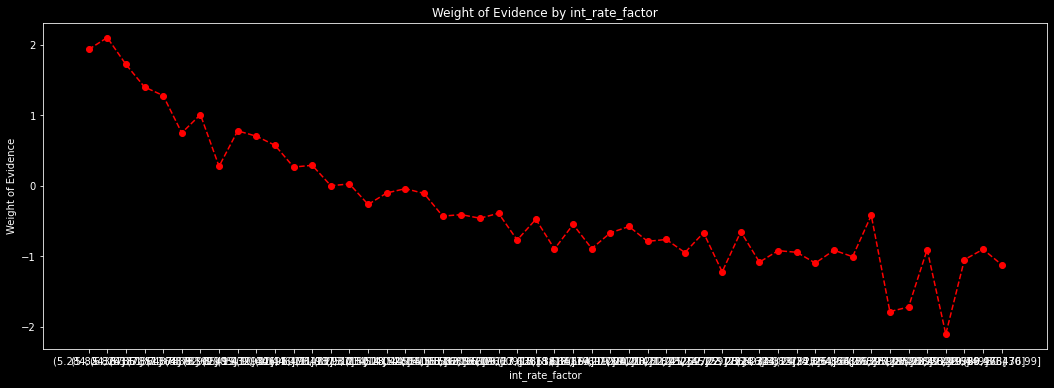

,int_rate_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(5.284, 5.824]",56721,0.979637,0.025144,55566.0,1155.0,0.028176,0.004071,1.934600,0.471695
1,"(5.824, 6.337]",48929,0.982751,0.021690,48085.0,844.0,0.024383,0.002975,2.103702,0.471695
2,"(6.337, 6.851]",51676,0.974979,0.022908,50383.0,1293.0,0.025548,0.004557,1.723818,0.471695
3,"(6.851, 7.364]",95053,0.965809,0.042137,91803.0,3250.0,0.046551,0.011455,1.402119,0.471695
4,"(7.364, 7.878]",54395,0.961596,0.024113,52306.0,2089.0,0.026523,0.007363,1.281555,0.471695
5,"(7.878, 8.392]",137960,0.936460,0.061157,129194.0,8766.0,0.065511,0.030897,0.751564,0.471695
6,"(8.392, 8.905]",37143,0.950246,0.016465,35295.0,1848.0,0.017897,0.006513,1.010766,0.471695
7,"(8.905, 9.419]",46430,0.901680,0.020582,41865.0,4565.0,0.021229,0.016090,0.277161,0.471695
8,"(9.419, 9.932]",99514,0.938159,0.044114,93360.0,6154.0,0.047340,0.021690,0.780490,0.471695
9,"(9.932, 10.446]",78639,0.933646,0.034860,73421.0,5218.0,0.037230,0.018391,0.705225,0.471695


In [154]:
df_input['int_rate_factor'] = pd.cut(df_input['int_rate'], 50)
df_temp = woe_discrete(df_input, 'int_rate_factor', df_output)
plot_by_woe_v2(df_temp, 'int_rate_factor')
df_temp

In [155]:
df_input['int_rate:<9.548'] = np.where((df_input['int_rate'] <= 9.548), 1, 0)
df_input['int_rate:9.548-12.025'] = np.where((df_input['int_rate'] > 9.548) & (df_input['int_rate'] <= 12.025), 1, 0)
df_input['int_rate:12.025-15.74'] = np.where((df_input['int_rate'] > 12.025) & (df_input['int_rate'] <= 15.74), 1, 0)
df_input['int_rate:15.74-20.281'] = np.where((df_input['int_rate'] > 15.74) & (df_input['int_rate'] <= 20.281), 1, 0)
df_input['int_rate:>20.281'] = np.where((df_input['int_rate'] > 20.281), 1, 0)

credit history

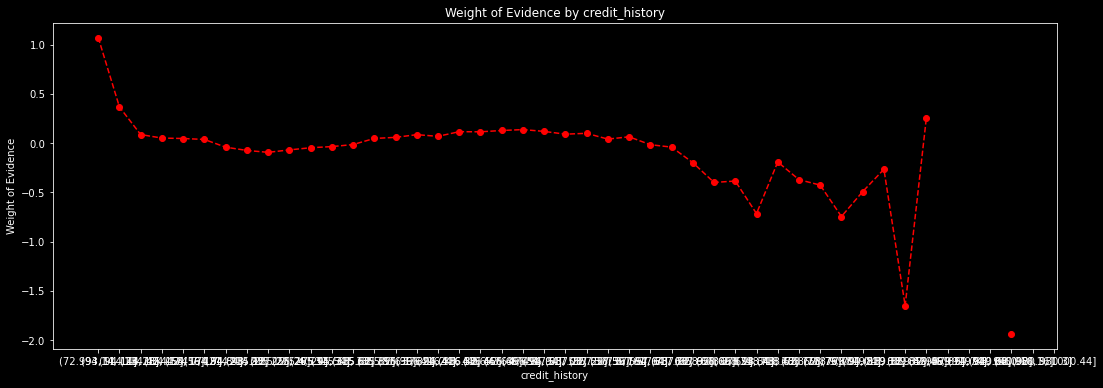

,credit_history,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(72.993, 94.14]",17210,0.953109,7.629151e-03,16403.0,807.0,8.317521e-03,0.002844,1.073025,inf
1,"(94.14, 114.28]",37906,0.909407,1.680364e-02,34472.0,3434.0,1.747983e-02,0.012104,0.367551,inf
2,"(114.28, 134.42]",58178,0.883547,2.579017e-02,51403.0,6775.0,2.606508e-02,0.023879,0.087586,inf
3,"(134.42, 154.56]",66539,0.879845,2.949658e-02,58544.0,7995.0,2.968609e-02,0.028179,0.052091,inf
4,"(154.56, 174.7]",99787,0.879363,4.423534e-02,87749.0,12038.0,4.449516e-02,0.042429,0.047541,inf
5,"(174.7, 194.84]",192720,0.878347,8.543231e-02,169275.0,23445.0,8.583481e-02,0.082635,0.037996,inf
6,"(194.84, 214.98]",239516,0.869712,1.061769e-01,208310.0,31206.0,1.056284e-01,0.109989,-0.040454,inf
7,"(214.98, 235.12]",247729,0.865914,1.098177e-01,214512.0,33217.0,1.087733e-01,0.117077,-0.073567,inf
8,"(235.12, 255.26]",207640,0.863653,9.204631e-02,179329.0,28311.0,9.093292e-02,0.099785,-0.092899,inf
9,"(255.26, 275.4]",212422,0.866530,9.416616e-02,184070.0,28352.0,9.333696e-02,0.099930,-0.068252,inf


In [163]:
df_input['credit_history_cate'] = pd.cut(df_input['credit_history'], 50)
df_temp = woe_discrete(df_input, 'credit_history_cate', df_output)
plot_by_woe_v2(df_temp, 'credit_history_cate')
df_temp

In [164]:
# Coarse binning step
df_input['credit_history:< 114.28'] = np.where((df_input['credit_history_cate'] <=  114.28), 1, 0)
df_input['credit_history:114.28-658.06'] = np.where((df_input['credit_history_cate'] >114.28) & (df_input['credit_history'] <= 658.06), 1, 0)
df_input['credit_history:>658.06'] = np.where((df_input['credit_history_cate'] > 658.06), 1, 0)

TypeError: Invalid comparison between dtype=category and float

inq_last_6mths

c:\Users\ASUS\anaconda3\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


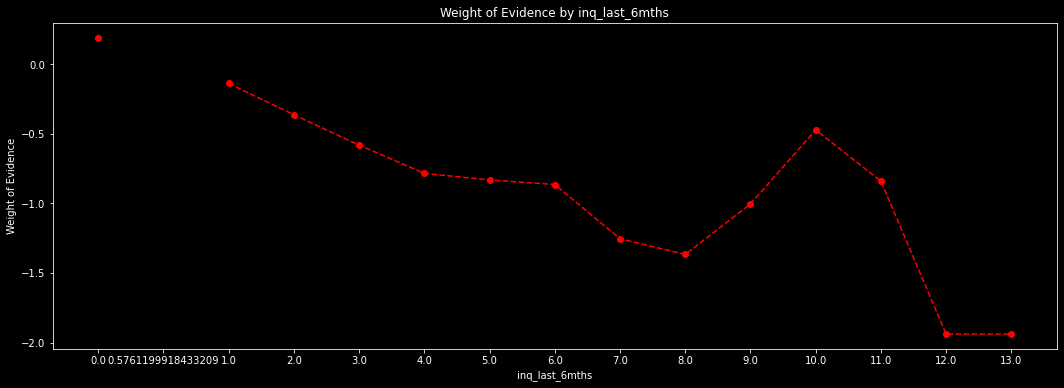

,inq_last_6mths,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,0.00000,1378649,0.893749,6.111518e-01,1232166.0,146483.0,6.247983e-01,0.516296,0.190749,inf
1,0.57612,1,1.000000,4.432976e-07,1.0,0.0,5.070732e-07,0.000000,inf,inf
2,1.00000,583463,0.858125,2.586477e-01,500684.0,82779.0,2.538834e-01,0.291764,-0.139070,inf
3,2.00000,199893,0.828558,8.861208e-02,165623.0,34270.0,8.398298e-02,0.120789,-0.363427,inf
4,3.00000,68825,0.795278,3.050996e-02,54735.0,14090.0,2.775465e-02,0.049662,-0.581833,inf
5,4.00000,17276,0.760303,7.658409e-03,13135.0,4141.0,6.660406e-03,0.014595,-0.784528,inf
6,5.00000,6175,0.751579,2.737363e-03,4641.0,1534.0,2.353327e-03,0.005407,-0.831820,inf
7,6.00000,1190,0.745378,5.275241e-04,887.0,303.0,4.497739e-04,0.001068,-0.864759,inf
8,7.00000,176,0.664773,7.802037e-05,117.0,59.0,5.932756e-05,0.000208,-1.254234,inf
9,8.00000,97,0.639175,4.299987e-05,62.0,35.0,3.143854e-05,0.000123,-1.367085,inf


In [172]:
# df_input['inq_last_6mths_cate'] = pd.cut(df_input['inq_last_6mths'], 50)
df_temp = woe_discrete(df_input, 'inq_last_6mths', df_output)
plot_by_woe_v2(df_temp, 'inq_last_6mths')
df_temp

In [177]:
df_input['inq_last_6mths:0'] = np.where((df_input['inq_last_6mths'] == 0), 1, 0)
df_input['inq_last_6mths:1-2'] = np.where((df_input['inq_last_6mths'] >= 1) & (df_input['inq_last_6mths'] <= 2), 1, 0)
df_input['inq_last_6mths:3-6'] = np.where((df_input['inq_last_6mths'] >= 3) & (df_input['inq_last_6mths'] <= 6), 1, 0)
df_input['inq_last_6mths:>6'] = np.where((df_input['inq_last_6mths'] > 6) | (0< (df_input['inq_last_6mths'] <1)), 1, 0)

open_acc

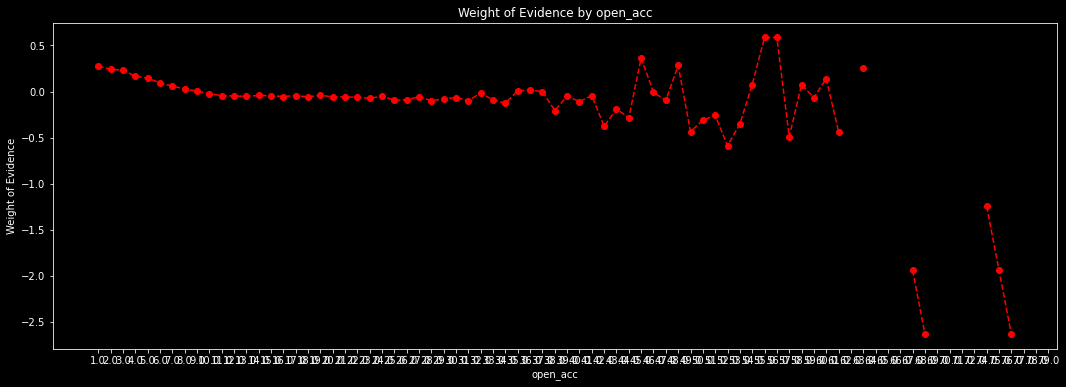

,open_acc,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,1.0,1402,0.901569,6.215032e-04,1264.0,138.0,6.409405e-04,0.000486,0.275912,inf
1,2.0,10429,0.898456,4.623151e-03,9370.0,1059.0,4.751276e-03,0.003733,0.241317,inf
2,3.0,31942,0.897627,1.415981e-02,28672.0,3270.0,1.453880e-02,0.011525,0.232260,inf
3,4.0,67367,0.891445,2.986363e-02,60054.0,7313.0,3.045177e-02,0.025776,0.166720,inf
4,5.0,108124,0.889248,4.793111e-02,96149.0,11975.0,4.875458e-02,0.042207,0.144207,inf
...,...,...,...,...,...,...,...,...,...,...
85,91.0,1,1.000000,4.432976e-07,1.0,0.0,5.070732e-07,0.000000,inf,inf
86,93.0,1,1.000000,4.432976e-07,1.0,0.0,5.070732e-07,0.000000,inf,inf
87,94.0,1,1.000000,4.432976e-07,1.0,0.0,5.070732e-07,0.000000,inf,inf
88,97.0,1,1.000000,4.432976e-07,1.0,0.0,5.070732e-07,0.000000,inf,inf


In [179]:
df_temp = woe_discrete(df_input, 'open_acc', df_output)
plot_by_woe_v2(df_temp, 'open_acc')
df_temp

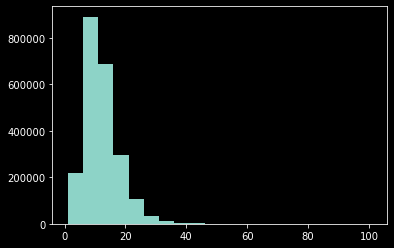

In [188]:
plt.hist (df_input['open_acc'], bins = 20)
plt.show()

In [189]:
# df_input['open_acc:1-4'] = np.where((df_input['open_acc'] == 1), 1, 0)
df_input['open_acc:1-4'] = np.where((df_input['open_acc'] >= 1) & (df_input['open_acc'] < 4), 1, 0)
df_input['open_acc:4-12'] = np.where((df_input['open_acc'] >= 4) & (df_input['open_acc'] <= 12), 1, 0)
df_input['open_acc:13-17'] = np.where((df_input['open_acc'] >= 13) & (df_input['open_acc'] <= 17), 1, 0)
df_input['open_acc:18-22'] = np.where((df_input['open_acc'] >= 18) & (df_input['open_acc'] <= 22), 1, 0)
df_input['open_acc:23-25'] = np.where((df_input['open_acc'] >= 23) & (df_input['open_acc'] <= 25), 1, 0)
df_input['open_acc:26-30'] = np.where((df_input['open_acc'] >= 26) & (df_input['open_acc'] <= 30), 1, 0)
df_input['open_acc:>=31'] = np.where((df_input['open_acc'] >= 31), 1, 0)

pub_rec


c:\Users\ASUS\anaconda3\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


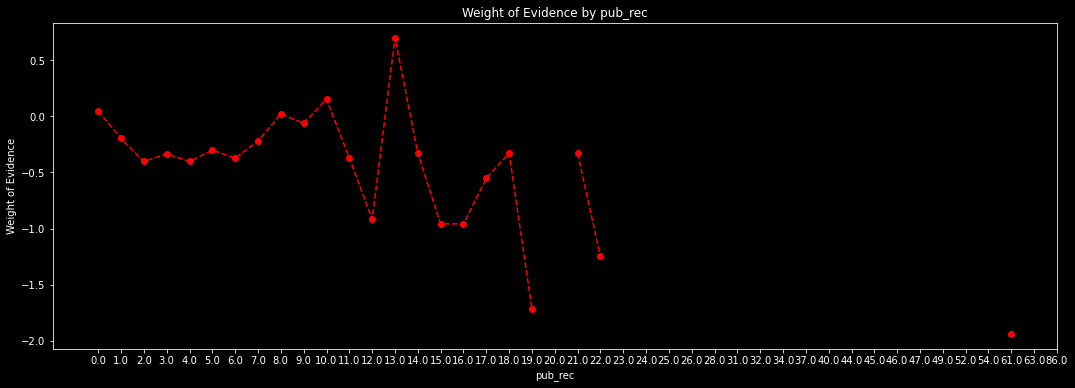

,pub_rec,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,0.0,1898258,0.879326,8.414932e-01,1669187.0,229071.0,8.463999e-01,0.807387,0.047189,inf
1,1.0,305096,0.850778,1.352483e-01,259569.0,45527.0,1.316205e-01,0.160465,-0.198154,inf
2,2.0,34139,0.823076,1.513374e-02,28099.0,6040.0,1.424825e-02,0.021289,-0.401541,inf
3,3.0,10563,0.832529,4.682552e-03,8794.0,1769.0,4.459201e-03,0.006235,-0.335216,inf
4,4.0,3870,0.822997,1.715562e-03,3185.0,685.0,1.615028e-03,0.002414,-0.402082,inf
5,5.0,1842,0.837134,8.165542e-04,1542.0,300.0,7.819068e-04,0.001057,-0.301818,inf
6,6.0,932,0.827253,4.131533e-04,771.0,161.0,3.909534e-04,0.000567,-0.372587,inf
7,7.0,427,0.847775,1.892881e-04,362.0,65.0,1.835605e-04,0.000229,-0.221614,inf
8,8.0,243,0.876543,1.077213e-04,213.0,30.0,1.080066e-04,0.000106,0.021224,inf
9,9.0,143,0.867133,6.339155e-05,124.0,19.0,6.287707e-05,0.000067,-0.063028,inf


In [191]:
df_temp = woe_discrete(df_input, 'pub_rec', df_output)
plot_by_woe_v2(df_temp, 'pub_rec')
df_temp

In [192]:
#create categories

df_input['pub_rec:0-2'] = np.where((df_input['pub_rec'] >= 0) & (df_input['pub_rec'] <= 2), 1, 0)
df_input['pub_rec:3-4'] = np.where((df_input['pub_rec'] >= 3) & (df_input['pub_rec'] <= 4), 1, 0)
df_input['pub_rec:>=5'] = np.where((df_input['pub_rec'] >= 5), 1, 0)

total_acc

In [193]:
df_input['total_acc_factor'] = pd.cut(df_input['total_acc'], 50)
df_temp = woe_discrete(df_input, 'total_acc_factor', df_output)
df_temp

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\492685077.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\492685077.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)
c:\Users\ASUS\anaconda3\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,total_acc_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(0.825, 4.5]",15767,0.893448,6.989473e-03,14087.0,1680.0,7.143140e-03,0.005921,0.187588,inf
1,"(4.5, 8.0]",109820,0.886651,4.868294e-02,97372.0,12448.0,4.937473e-02,0.043874,0.118108,inf
2,"(8.0, 11.5]",159110,0.881063,7.053308e-02,140186.0,18924.0,7.108456e-02,0.066700,0.063668,inf
3,"(11.5, 15.0]",286325,0.876839,1.269272e-01,251061.0,35264.0,1.273063e-01,0.124292,0.023962,inf
4,"(15.0, 18.5]",242436,0.875901,1.074713e-01,212350.0,30086.0,1.076770e-01,0.106042,0.015305,inf
5,"(18.5, 22.0]",324612,0.874734,1.438997e-01,283949.0,40663.0,1.439829e-01,0.143321,0.004605,inf
6,"(22.0, 25.5]",225144,0.873321,9.980579e-02,196623.0,28521.0,9.970225e-02,0.100526,-0.008223,inf
7,"(25.5, 29.0]",254289,0.872885,1.127257e-01,221965.0,32324.0,1.125525e-01,0.113930,-0.012161,inf
8,"(29.0, 32.5]",154190,0.871717,6.835205e-02,134410.0,19780.0,6.815570e-02,0.069717,-0.022647,inf
9,"(32.5, 36.0]",157476,0.870984,6.980873e-02,137159.0,20317.0,6.954965e-02,0.071610,-0.029188,inf


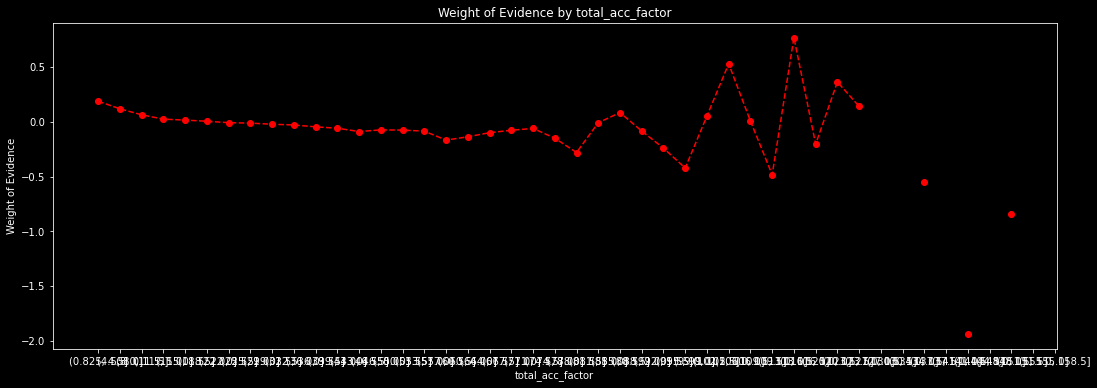

In [196]:
plot_by_woe_v2(df_temp, 'total_acc_factor')

In [197]:
df_input['total_acc:<=25.5'] = np.where((df_input['total_acc'] <= 25.5), 1, 0)
df_input['total_acc:25.5-51'] = np.where((df_input['total_acc'] >= 25.5) & (df_input['total_acc'] <= 51), 1, 0)
df_input['total_acc:>=52'] = np.where((df_input['total_acc'] >= 52), 1, 0)

acc_now_delinq

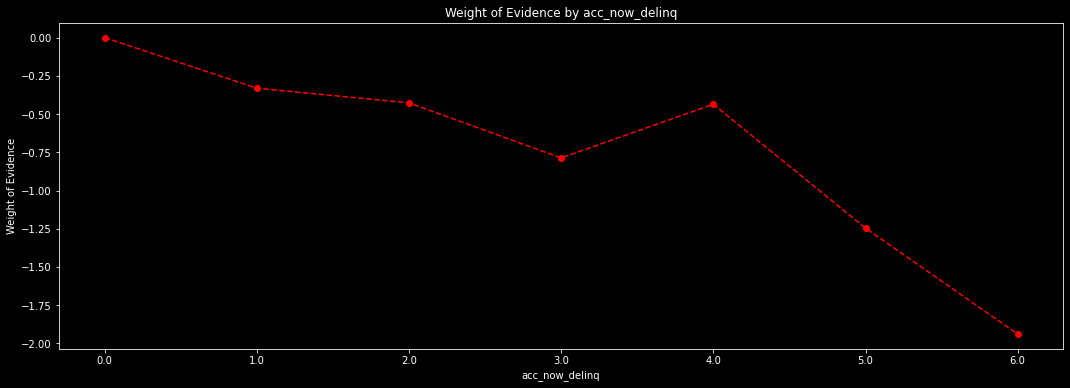

,acc_now_delinq,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,0.0,2247054,0.874392,9.961136e-01,1964807.0,282247.0,9.963009e-01,0.994812,0.001496,inf
1,1.0,8278,0.833293,3.669617e-03,6898.0,1380.0,3.497791e-03,0.004864,-0.329723,inf
2,2.0,421,0.819477,1.866283e-04,345.0,76.0,1.749402e-04,0.000268,-0.426060,inf
3,3.0,50,0.760000,2.216488e-05,38.0,12.0,1.926878e-05,0.000042,-0.786191,inf
4,4.0,11,0.818182,4.876273e-06,9.0,2.0,4.563658e-06,0.000007,-0.434794,inf
5,5.0,3,0.666667,1.329893e-06,2.0,1.0,1.014146e-06,0.000004,-1.245724,inf
6,6.0,2,0.500000,8.865952e-07,1.0,1.0,5.070732e-07,0.000004,-1.938871,inf
7,7.0,1,1.000000,4.432976e-07,1.0,0.0,5.070732e-07,0.000000,inf,inf
8,14.0,1,1.000000,4.432976e-07,1.0,0.0,5.070732e-07,0.000000,inf,inf


In [199]:
df_temp = woe_discrete(df_input,'acc_now_delinq', df_output)
plot_by_woe_v2(df_temp, 'acc_now_delinq')
df_temp

In [201]:
df_input['acc_now_delinq:0'] = np.where((df_input['acc_now_delinq'] == 0), 1, 0)
df_input['acc_now_delinq:>=1'] = np.where((df_input['acc_now_delinq'] >= 1), 1, 0)

total_rev_hi_lim

In [202]:
df_input['total_rev_hi_lim_factor'] = pd.cut(df_input['total_rev_hi_lim'], 2000)
df_temp = woe_discrete(df_input, 'total_rev_hi_lim_factor', df_output)
df_temp.tail(50)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\492685077.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\492685077.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)
c:\Users\ASUS\anaconda3\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,total_rev_hi_lim_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
1950,"(9749999.025, 9754999.024]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,inf
1951,"(9754999.024, 9759999.024]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,inf
1952,"(9759999.024, 9764999.024]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,inf
1953,"(9764999.024, 9769999.023]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,inf
1954,"(9769999.023, 9774999.022]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,inf
1955,"(9774999.022, 9779999.022]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,inf
1956,"(9779999.022, 9784999.022]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,inf
1957,"(9784999.022, 9789999.021]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,inf
1958,"(9789999.021, 9794999.02]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,inf
1959,"(9794999.02, 9799999.02]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,inf


In [203]:
df_input['total_rev_hi_lim:<=5K'] = np.where((df_input['total_rev_hi_lim'] <= 5000), 1, 0)
df_input['total_rev_hi_lim:5K-10K'] = np.where((df_input['total_rev_hi_lim'] > 5000) & (df_input['total_rev_hi_lim'] <= 10000), 1, 0)
df_input['total_rev_hi_lim:10K-20K'] = np.where((df_input['total_rev_hi_lim'] > 10000) & (df_input['total_rev_hi_lim'] <= 20000), 1, 0)
df_input['total_rev_hi_lim:20K-30K'] = np.where((df_input['total_rev_hi_lim'] > 20000) & (df_input['total_rev_hi_lim'] <= 30000), 1, 0)
df_input['total_rev_hi_lim:30K-40K'] = np.where((df_input['total_rev_hi_lim'] > 30000) & (df_input['total_rev_hi_lim'] <= 40000), 1, 0)
df_input['total_rev_hi_lim:40K-55K'] = np.where((df_input['total_rev_hi_lim'] > 40000) & (df_input['total_rev_hi_lim'] <= 55000), 1, 0)
df_input['total_rev_hi_lim:55K-95K'] = np.where((df_input['total_rev_hi_lim'] > 55000) & (df_input['total_rev_hi_lim'] <= 95000), 1, 0)
df_input['total_rev_hi_lim:>95K'] = np.where((df_input['total_rev_hi_lim'] > 95000), 1, 0)

annual_inc_factor

In [204]:
# Create a feature named "annual_inc_factor" using pd.cut (Fine classing)

df_input['annual_inc_factor'] = pd.cut(df_input['annual_inc'], 50)

# Compute WoE

df_temp = woe_discrete(df_input, 'annual_inc_factor', df_output)


df_temp

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\492685077.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\492685077.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


,annual_inc_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(-110000.0, 2200000.0]",2255630,0.874227,9.999153e-01,1971933.0,283697.0,9.999143e-01,0.999922,-0.000008,inf
1,"(2200000.0, 4400000.0]",79,0.860759,3.502051e-05,68.0,11.0,3.448098e-05,0.000039,-0.117259,inf
2,"(4400000.0, 6600000.0]",57,0.894737,2.526796e-05,51.0,6.0,2.586073e-05,0.000021,0.201195,inf
3,"(6600000.0, 8800000.0]",38,0.947368,1.684531e-05,36.0,2.0,1.825463e-05,0.000007,0.951501,inf
4,"(8800000.0, 11000000.0]",15,0.800000,6.649464e-06,12.0,3.0,6.084878e-06,0.000011,-0.552577,inf
5,"(11000000.0, 13200000.0]",0,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,inf
6,"(13200000.0, 15400000.0]",0,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,inf
7,"(15400000.0, 17600000.0]",0,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,inf
8,"(17600000.0, 19800000.0]",0,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,inf
9,"(19800000.0, 22000000.0]",0,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,inf


In [207]:
df_inputs_prepr_temp = df_input.loc[df_input['annual_inc'] <= 140000, : ]
df_inputs_prepr_temp["annual_inc_factor"] = pd.cut(df_inputs_prepr_temp['annual_inc'], 50)

# Compute WoE
df_temp = woe_discrete(df_inputs_prepr_temp, 'annual_inc_factor', df_output[df_inputs_prepr_temp.index])

df_temp

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\4090327718.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_inputs_prepr_temp["annual_inc_factor"] = pd.cut(df_inputs_prepr_temp['annual_inc'], 50)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\492685077.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\492685077.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True 

,annual_inc_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(-140.0, 2800.0]",389,0.930591,0.000187,362.0,27.0,0.000200,0.000101,0.686418,0.023317
1,"(2800.0, 5600.0]",514,0.943580,0.000247,485.0,29.0,0.000268,0.000108,0.907464,0.023317
2,"(5600.0, 8400.0]",894,0.903803,0.000430,808.0,86.0,0.000446,0.000320,0.330826,0.023317
3,"(8400.0, 11200.0]",3657,0.860268,0.001758,3146.0,511.0,0.001736,0.001903,-0.091872,0.023317
4,"(11200.0, 14000.0]",6333,0.858203,0.003044,5435.0,898.0,0.003000,0.003345,-0.108944,0.023317
5,"(14000.0, 16800.0]",9287,0.854097,0.004464,7932.0,1355.0,0.004378,0.005047,-0.142285,0.023317
6,"(16800.0, 19600.0]",10975,0.847836,0.005276,9305.0,1670.0,0.005136,0.006221,-0.191661,0.023317
7,"(19600.0, 22400.0]",22022,0.849923,0.010586,18717.0,3305.0,0.010331,0.012311,-0.175393,0.023317
8,"(22400.0, 25200.0]",36542,0.849981,0.017566,31060.0,5482.0,0.017143,0.020420,-0.174938,0.023317
9,"(25200.0, 28000.0]",30743,0.843119,0.014778,25920.0,4823.0,0.014306,0.017966,-0.227770,0.023317


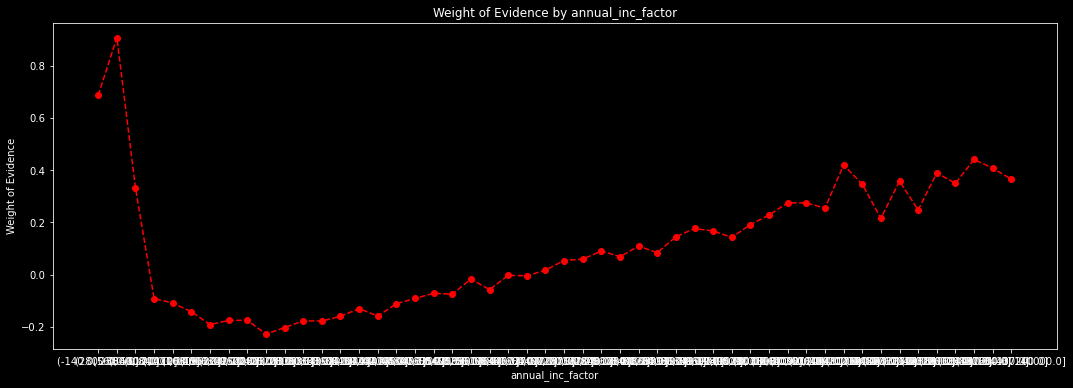

In [209]:
plot_by_woe_v2(df_temp, 'annual_inc_factor')

In [222]:
# df_inputs_prepr = df_input
df_input['annual_inc:<8k4'] = np.where((df_input['annual_inc'] <= 8400), 1, 0)
df_input['annual_inc:8k4-20k'] = np.where((df_input['annual_inc'] > 8400) & (df_inputs_prepr['annual_inc'] <= 20000), 1, 0)
df_input['annual_inc:20K-30K'] = np.where((df_input['annual_inc'] > 20000) & (df_inputs_prepr['annual_inc'] <= 30000), 1, 0)
df_input['annual_inc:30K-40K'] = np.where((df_input['annual_inc'] > 30000) & (df_inputs_prepr['annual_inc'] <= 40000), 1, 0)
df_input['annual_inc:40K-50K'] = np.where((df_input['annual_inc'] > 40000) & (df_inputs_prepr['annual_inc'] <= 50000), 1, 0)
df_input['annual_inc:50K-60K'] = np.where((df_input['annual_inc'] > 50000) & (df_inputs_prepr['annual_inc'] <= 60000), 1, 0)
df_input['annual_inc:60K-70K'] = np.where((df_input['annual_inc'] > 60000) & (df_inputs_prepr['annual_inc'] <= 70000), 1, 0)
df_input['annual_inc:70K-80K'] = np.where((df_input['annual_inc'] > 70000) & (df_inputs_prepr['annual_inc'] <= 80000), 1, 0)
df_input['annual_inc:80K-90K'] = np.where((df_input['annual_inc'] > 80000) & (df_inputs_prepr['annual_inc'] <= 90000), 1, 0)
df_input['annual_inc:90K-100K'] = np.where((df_input['annual_inc'] > 90000) & (df_inputs_prepr['annual_inc'] <= 100000), 1, 0)
df_input['annual_inc:100K-120K'] = np.where((df_input['annual_inc'] > 100000) & (df_inputs_prepr['annual_inc'] <= 120000), 1, 0)
df_input['annual_inc:120K-140K'] = np.where((df_input['annual_inc'] > 120000) & (df_inputs_prepr['annual_inc'] <= 140000), 1, 0)
df_input['annual_inc:>140K'] = np.where((df_input['annual_inc'] > 140000), 1, 0)

In [213]:
df_input['mths_since_last_delinq'].value_counts()

mths_since_last_delinq
0.0      1158439
12.0       20918
13.0       20576
6.0        20565
9.0        20299
          ...   
168.0          1
192.0          1
226.0          1
179.0          1
202.0          1
Name: count, Length: 173, dtype: int64

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\492685077.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\492685077.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)
c:\Users\ASUS\anaconda3\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


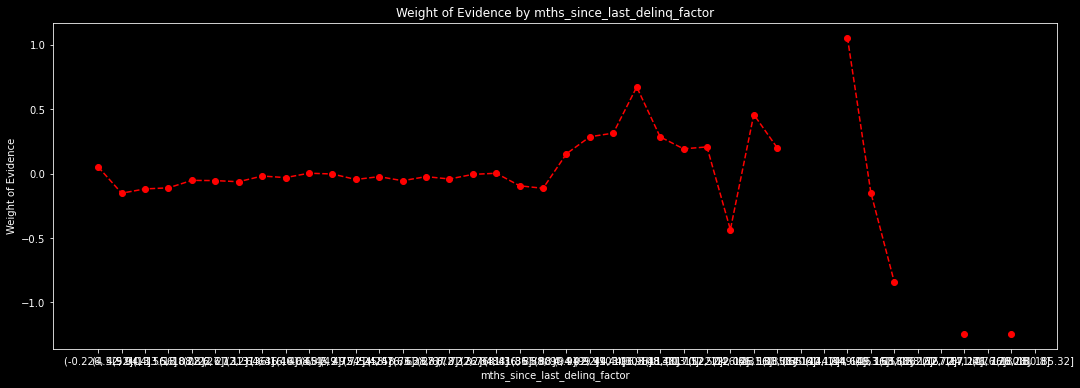

,mths_since_last_delinq_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(-0.226, 4.52]",1203888,0.879834,5.336806e-01,1059222.0,144666.0,5.371031e-01,0.509892,0.051991,inf
1,"(4.52, 9.04]",97797,0.856580,4.335317e-02,83771.0,14026.0,4.247803e-02,0.049436,-0.151697,inf
2,"(9.04, 13.56]",79793,0.860627,3.537204e-02,68672.0,11121.0,3.482173e-02,0.039197,-0.118365,inf
3,"(13.56, 18.08]",95691,0.861596,4.241959e-02,82447.0,13244.0,4.180666e-02,0.046680,-0.110260,inf
4,"(18.08, 22.6]",73928,0.868372,3.277210e-02,64197.0,9731.0,3.255258e-02,0.034298,-0.052231,inf
5,"(22.6, 27.12]",89373,0.868170,3.961884e-02,77591.0,11782.0,3.934431e-02,0.041527,-0.053992,inf
6,"(27.12, 31.64]",67865,0.867177,3.008439e-02,58851.0,9014.0,2.984176e-02,0.031771,-0.062641,inf
7,"(31.64, 36.16]",79845,0.872190,3.539510e-02,69640.0,10205.0,3.531258e-02,0.035969,-0.018410,inf
8,"(36.16, 40.68]",60521,0.870805,2.682881e-02,52702.0,7819.0,2.672377e-02,0.027559,-0.030774,inf
9,"(40.68, 45.2]",72721,0.874603,3.223704e-02,63602.0,9119.0,3.225087e-02,0.032141,0.003414,inf


In [220]:
df_input['mths_since_last_delinq_factor'] = pd.cut(df_input['mths_since_last_delinq'], 50)
df_temp = woe_discrete(df_input, 'mths_since_last_delinq_factor', df_output)
plot_by_woe_v2(df_temp, 'mths_since_last_delinq_factor')
df_temp

In [221]:
# Create the categories
df_input['mths_since_last_delinq:Missing'] = np.where((df_input['mths_since_last_delinq'].isnull()), 1, 0)
df_input['mths_since_last_delinq:0-3'] = np.where((df_input['mths_since_last_delinq'] >= 0) & (df_input['mths_since_last_delinq'] <= 3), 1, 0)
df_input['mths_since_last_delinq:4-30'] = np.where((df_input['mths_since_last_delinq'] >= 4) & (df_input['mths_since_last_delinq'] <= 30), 1, 0)
df_input['mths_since_last_delinq:31-56'] = np.where((df_input['mths_since_last_delinq'] >= 31) & (df_input['mths_since_last_delinq'] <= 56), 1, 0)
df_input['mths_since_last_delinq:>=57'] = np.where((df_input['mths_since_last_delinq'] >= 57), 1, 0)

dti 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\3343541221.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\3343541221.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)
c:\Users\ASUS\anaconda3\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


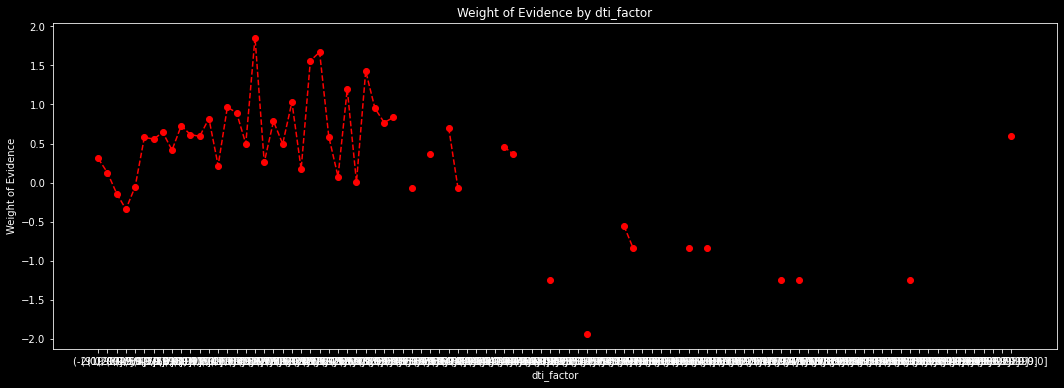

In [224]:
df_input['dti_factor'] = pd.cut(df_input['dti'], 100)
#Compute WoE
df_temp = woe_ordered_continuous(df_input, 'dti_factor', df_output)
plot_by_woe_v2(df_temp, 'dti_factor')

In [226]:
# most value smaller than 29
df_inputs_prepr_temp = df_input.loc[df_input['dti'] <= 39, : ]

In [231]:
df_inputs_prepr_temp['dti_factor'] = pd.cut(df_inputs_prepr_temp['dti'], 40)
#Compute WoE
df_temp = woe_discrete(df_inputs_prepr_temp, 'dti_factor', df_output[df_inputs_prepr_temp.index])
df_temp

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\3383914159.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_inputs_prepr_temp['dti_factor'] = pd.cut(df_inputs_prepr_temp['dti'], 40)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\492685077.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\492685077.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future ve

,dti_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(-1.04, 0.0]",1600,0.890000,0.000720,1424.0,176.0,0.000734,0.000629,0.154488,0.045875
1,"(0.0, 1.0]",9650,0.900829,0.004345,8693.0,957.0,0.004479,0.003419,0.270216,0.045875
2,"(1.0, 2.0]",16297,0.900657,0.007339,14678.0,1619.0,0.007563,0.005783,0.268288,0.045875
3,"(2.0, 3.0]",22227,0.907455,0.010009,20170.0,2057.0,0.010393,0.007348,0.346694,0.045875
4,"(3.0, 4.0]",29130,0.906111,0.013117,26395.0,2735.0,0.013600,0.009770,0.330790,0.045875
5,"(4.0, 5.0]",36014,0.907508,0.016217,32683.0,3331.0,0.016840,0.011899,0.347329,0.045875
6,"(5.0, 6.0]",43720,0.904597,0.019687,39549.0,4171.0,0.020378,0.014899,0.313131,0.045875
7,"(6.0, 7.0]",50960,0.905416,0.022948,46140.0,4820.0,0.023774,0.017218,0.322653,0.045875
8,"(7.0, 8.0]",58577,0.903324,0.026377,52914.0,5663.0,0.027264,0.020229,0.298461,0.045875
9,"(8.0, 9.0]",65982,0.903171,0.029712,59593.0,6389.0,0.030706,0.022822,0.296707,0.045875


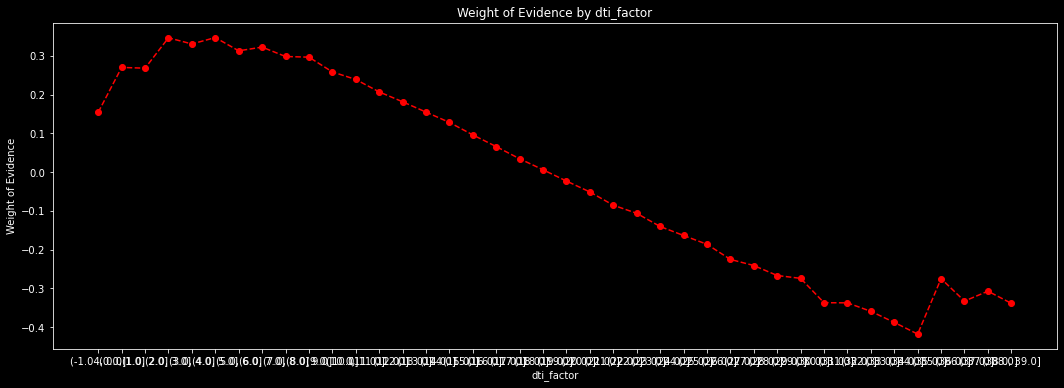

In [233]:
plot_by_woe_v2 (df_temp, 'dti_factor')

In [234]:
# Create categories
df_input['dti:<=1'] = np.where((df_input['dti'] <= 1), 1, 0)
df_input['dti:1-10'] = np.where((df_input['dti'] > 1) & (df_input['dti'] <= 10), 1, 0)
df_input['dti:10-23'] = np.where((df_input['dti'] > 10) & (df_input['dti'] <= 23), 1, 0)
df_input['dti:>22'] = np.where((df_input['dti'] > 22), 1, 0)

mths_since_last_record

In [241]:
df_input['mths_since_last_record_factor'] = pd.cut(df_input['mths_since_last_record'], 50)

# Compute WoE
df_temp = woe_discrete(df_input, 'mths_since_last_record_factor', df_output)

df_temp

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\492685077.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\492685077.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


,mths_since_last_record_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(-0.127, 2.54]",1898621,0.879313,0.841654,1669482.0,229139.0,0.846550,0.807627,0.047069,inf
1,"(2.54, 5.08]",1129,0.822852,0.000500,929.0,200.0,0.000471,0.000705,-0.403080,inf
2,"(5.08, 7.62]",1058,0.832703,0.000469,881.0,177.0,0.000447,0.000624,-0.333963,inf
3,"(7.62, 10.16]",1959,0.828484,0.000868,1623.0,336.0,0.000823,0.001184,-0.363951,inf
4,"(10.16, 12.7]",1479,0.814740,0.000656,1205.0,274.0,0.000611,0.000966,-0.457764,inf
5,"(12.7, 15.24]",2320,0.844397,0.001028,1959.0,361.0,0.000993,0.001272,-0.247559,inf
6,"(15.24, 17.78]",1610,0.846584,0.000714,1363.0,247.0,0.000691,0.000871,-0.230816,inf
7,"(17.78, 20.32]",2813,0.840384,0.001247,2364.0,449.0,0.001199,0.001583,-0.277783,inf
8,"(20.32, 22.86]",1963,0.844116,0.000870,1657.0,306.0,0.000840,0.001079,-0.249692,inf
9,"(22.86, 25.4]",3408,0.831279,0.001511,2833.0,575.0,0.001437,0.002027,-0.344149,inf


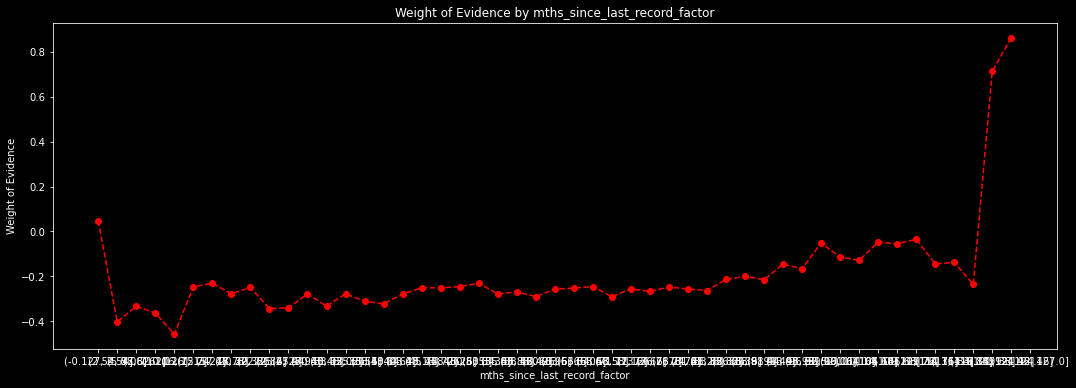

In [238]:
plot_by_woe_v2(df_temp, 'mths_since_last_record_factor')

In [242]:
# Create Categories


df_input['mths_since_last_record:0'] = np.where((df_input['mths_since_last_record']==0), 1, 0)
df_input['mths_since_last_record:1-92'] = np.where((df_input['mths_since_last_record'] >= 1) & (df_input['mths_since_last_record'] <= 92), 1, 0)
df_input['mths_since_last_record:>92'] = np.where((df_input['mths_since_last_record'] >= 92), 1, 0)


In [244]:
df_input.shape

(2255821, 340)

pct_tl_nvr_dlq

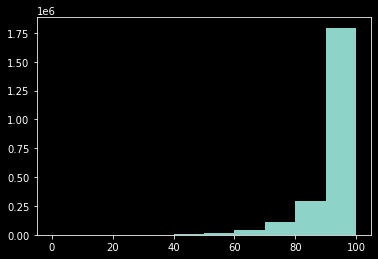

In [246]:
plt.hist (df_input['pct_tl_nvr_dlq'])
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\492685077.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\492685077.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


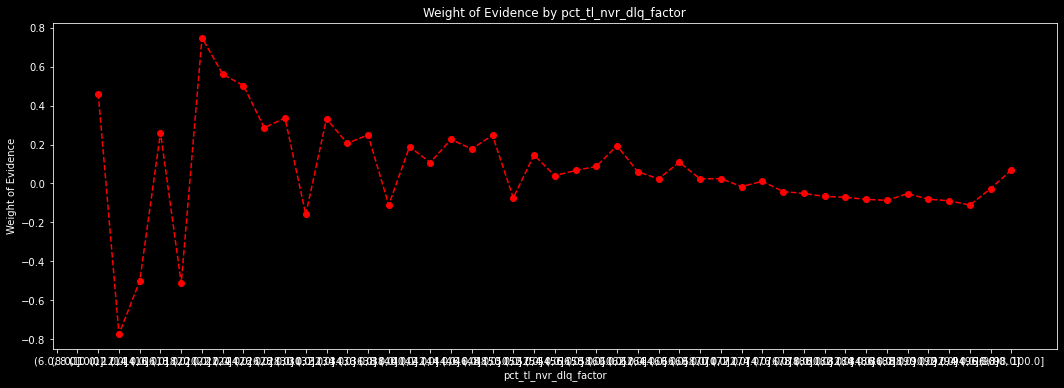

,pct_tl_nvr_dlq_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(-0.1, 2.0]",12,1.000000,5.403653e-06,12.0,0.0,0.000006,0.000000,inf,inf
1,"(2.0, 4.0]",0,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,inf
2,"(4.0, 6.0]",2,1.000000,9.006088e-07,2.0,0.0,0.000001,0.000000,inf,inf
3,"(6.0, 8.0]",6,1.000000,2.701826e-06,6.0,0.0,0.000003,0.000000,inf,inf
4,"(8.0, 10.0]",4,1.000000,1.801218e-06,4.0,0.0,0.000002,0.000000,inf,inf
5,"(10.0, 12.0]",12,0.916667,5.403653e-06,11.0,1.0,0.000006,0.000004,0.461642,inf
6,"(12.0, 14.0]",21,0.761905,9.456393e-06,16.0,5.0,0.000008,0.000018,-0.773103,inf
7,"(14.0, 16.0]",26,0.807692,1.170791e-05,21.0,5.0,0.000011,0.000018,-0.501169,inf
8,"(16.0, 18.0]",40,0.900000,1.801218e-05,36.0,4.0,0.000019,0.000014,0.260971,inf
9,"(18.0, 20.0]",67,0.805970,3.017040e-05,54.0,13.0,0.000028,0.000046,-0.512219,inf


In [248]:

df_input['pct_tl_nvr_dlq_factor'] = pd.cut(df_inputs_prepr_temp['pct_tl_nvr_dlq'], 50)

df_temp = woe_discrete(df_input, 'pct_tl_nvr_dlq_factor', df_output)
plot_by_woe_v2(df_temp, 'pct_tl_nvr_dlq_factor')
df_temp

In [249]:
df_input['pct_tl_nvr_dlq:<=68'] = np.where((df_input['pct_tl_nvr_dlq']<=68), 1, 0)
df_input['pct_tl_nvr_dlq:68-80'] = np.where((df_input['pct_tl_nvr_dlq'] > 68) & (df_input['pct_tl_nvr_dlq'] <= 80), 1, 0)
df_input['pct_tl_nvr_dlq:80-99'] = np.where((df_input['pct_tl_nvr_dlq'] > 80) & (df_input['pct_tl_nvr_dlq'] <= 99), 1, 0)
df_input['pct_tl_nvr_dlq:100'] = np.where((df_input['pct_tl_nvr_dlq'] ) == 100, 1, 0)

bc_util

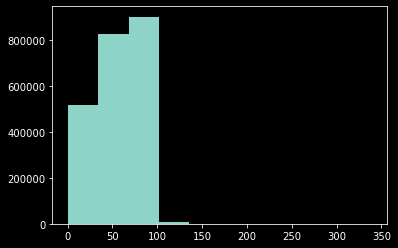

In [250]:
plt.hist (df_input['bc_util'])
plt.show()

In [252]:
df_input['bc_util'].value_counts()

bc_util
57.901243     72891
0.000000      27831
98.000000      6183
97.000000      5743
99.000000      5697
              ...  
136.200000        1
194.000000        1
182.800000        1
148.400000        1
130.900000        1
Name: count, Length: 1495, dtype: int64

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\492685077.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\492685077.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)
c:\Users\ASUS\anaconda3\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


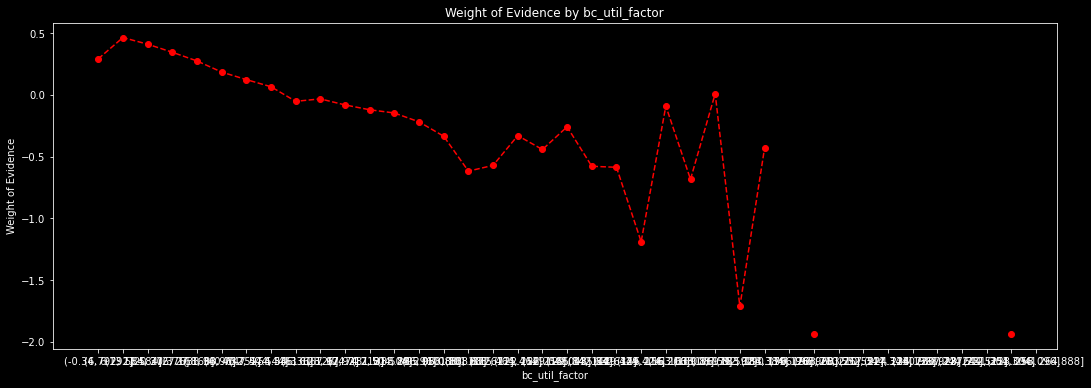

,bc_util_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(-0.34, 6.792]",97878,0.902716,4.407489e-02,88356.0,9522.0,4.552612e-02,0.034014,0.291516,inf
1,"(6.792, 13.584]",78220,0.916824,3.522281e-02,71714.0,6506.0,3.695120e-02,0.023240,0.463708,inf
2,"(13.584, 20.376]",95603,0.912649,4.305045e-02,87252.0,8351.0,4.495727e-02,0.029831,0.410166,inf
3,"(20.376, 27.168]",112631,0.907308,5.071824e-02,102191.0,10440.0,5.265471e-02,0.037293,0.344945,inf
4,"(27.168, 33.96]",126785,0.901211,5.709184e-02,114260.0,12525.0,5.887336e-02,0.044741,0.274496,inf
5,"(33.96, 40.752]",138019,0.892906,6.215056e-02,123238.0,14781.0,6.349934e-02,0.052800,0.184521,inf
6,"(40.752, 47.544]",145551,0.886926,6.554226e-02,129093.0,16458.0,6.651618e-02,0.058790,0.123468,inf
7,"(47.544, 54.336]",150105,0.881010,6.759294e-02,132244.0,17861.0,6.813975e-02,0.063802,0.065776,inf
8,"(54.336, 61.128]",226025,0.868041,1.017801e-01,196199.0,29826.0,1.010931e-01,0.106543,-0.052505,inf
9,"(61.128, 67.92]",155081,0.870300,6.983366e-02,134967.0,20114.0,6.954280e-02,0.071850,-0.032639,inf


In [253]:
df_input['bc_util_factor'] = pd.cut(df_inputs_prepr_temp['bc_util'], 50)

df_temp = woe_discrete(df_input, 'bc_util_factor', df_output)
plot_by_woe_v2(df_temp, 'bc_util_factor')
df_temp

In [254]:
df_input['bc_util:<=33.96'] = np.where((df_input['bc_util']<=33.96), 1, 0)
df_input['bc_util:33.96-61.128'] = np.where((df_input['bc_util'] > 33.96) & (df_input['bc_util'] <= 61.128), 1, 0)
df_input['bc_util:61.128-101.88'] = np.where((df_input['bc_util'] > 61.128) & (df_input['bc_util'] <= 101.88), 1, 0)
df_input['bc_util:>101.88'] = np.where((df_input['bc_util'] ) >101.88, 1, 0)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\211661090.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_input['bc_util:<=33.96'] = np.where((df_input['bc_util']<=33.96), 1, 0)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\211661090.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_input['bc_util:33.96-61.128'] = np.where((df_input['bc_util'] > 33.96) & (df_input['bc_util'] <= 61.128), 1, 0)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\211661090.py:3: PerformanceWarning: DataFrame is highly fragmented.  This

percent_bc_gt_75

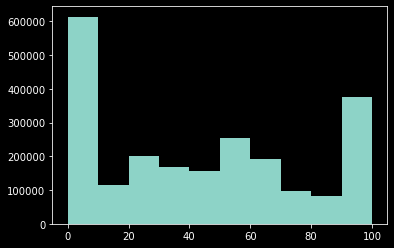

In [255]:
plt.hist (df_input['percent_bc_gt_75'])
plt.show()

In [257]:
df_input['percent_bc_gt_75'].value_counts()

percent_bc_gt_75
0.0      598086
100.0    372256
50.0     231715
33.3     147160
66.7     134632
          ...  
36.7          1
7.5           1
20.7          1
8.8           1
2.4           1
Name: count, Length: 285, dtype: int64

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\3288340059.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_input['percent_bc_gt_75_factor'] = pd.cut(df_inputs_prepr_temp['percent_bc_gt_75'], 50)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\492685077.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\492685077.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future

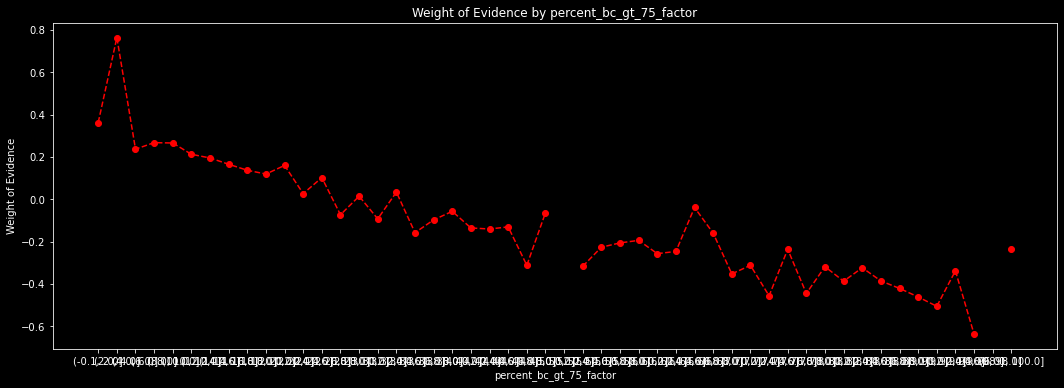

,percent_bc_gt_75_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(-0.1, 2.0]",591378,0.908745,2.663001e-01,537412.0,53966.0,0.276906,0.192774,0.362157,inf
1,"(2.0, 4.0]",127,0.937008,5.718866e-05,119.0,8.0,0.000061,0.000029,0.763428,inf
2,"(4.0, 6.0]",1389,0.897768,6.254728e-04,1247.0,142.0,0.000643,0.000507,0.236415,inf
3,"(6.0, 8.0]",4977,0.900542,2.241165e-03,4482.0,495.0,0.002309,0.001768,0.267013,inf
4,"(8.0, 10.0]",15362,0.900404,6.917576e-03,13832.0,1530.0,0.007127,0.005465,0.265463,inf
5,"(10.0, 12.0]",11772,0.895515,5.300983e-03,10542.0,1230.0,0.005432,0.004394,0.212100,inf
6,"(12.0, 14.0]",18224,0.893876,8.206347e-03,16290.0,1934.0,0.008394,0.006909,0.194707,inf
7,"(14.0, 16.0]",28714,0.891029,1.293004e-02,25585.0,3129.0,0.013183,0.011177,0.165039,inf
8,"(16.0, 18.0]",42037,0.888241,1.892945e-02,37339.0,4698.0,0.019239,0.016782,0.136648,inf
9,"(18.0, 20.0]",67915,0.886461,3.058242e-02,60204.0,7711.0,0.031021,0.027545,0.118837,inf


In [258]:
df_input['percent_bc_gt_75_factor'] = pd.cut(df_inputs_prepr_temp['percent_bc_gt_75'], 50)

df_temp = woe_discrete(df_input, 'percent_bc_gt_75_factor', df_output)
plot_by_woe_v2(df_temp, 'percent_bc_gt_75_factor')
df_temp

In [259]:
df_input['bc_util:0'] = np.where((df_input['bc_util']==0), 1, 0)
df_input['bc_util:0-30'] = np.where((df_input['bc_util'] > 0) & (df_input['bc_util'] <= 30), 1, 0)
df_input['bc_util:30-48'] = np.where((df_input['bc_util'] > 30) & (df_input['bc_util'] <= 48), 1, 0)
df_input['bc_util:48-50'] = np.where((df_input['bc_util'] > 48) & (df_input['bc_util'] <= 50), 1, 0)
df_input['bc_util:50-98'] = np.where((df_input['bc_util'] > 50) & (df_input['bc_util'] <= 98), 1, 0)
df_input['bc_util:98-100'] = np.where((df_input['bc_util'] > 98) & (df_input['bc_util'] <= 100), 1, 0)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\2526333501.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_input['bc_util:0'] = np.where((df_input['bc_util']==0), 1, 0)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\2526333501.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_input['bc_util:0-30'] = np.where((df_input['bc_util'] > 0) & (df_input['bc_util'] <= 30), 1, 0)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14228\2526333501.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result 

In [260]:
df_input.shape

(2255821, 357)

### ***MODEL***

In [1]:
# df_input.to_pickle('df_new.to_pickle')


c:\Users\ASUS\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\ASUS\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
df_input = pd.read_pickle('df_new.to_pickle')

In [3]:
# error fix #
# fix = [pd.get_dummies(df_input['next_pymnt_d'], prefix = 'next_pymnt_d', prefix_sep = ':',dtype='int'),
#                      pd.get_dummies(df_input['mths_since_last_major_derog'], prefix = 'mths_since_last_major_derog', prefix_sep = ':',dtype='int'),
#                      pd.get_dummies(df_input['funded_plt'], prefix = 'funded_plt', prefix_sep = ':',dtype='int'),
#                      pd.get_dummies(df_input['last_pymnt_d'], prefix = 'last_pymnt_d', prefix_sep = ':',dtype='int')]
# fix = pd.concat(fix,axis =1)
# fix_df = pd.concat([df, loan_data_dummies], axis = 1)

In [4]:
# df_input = pd.concat([fix, df_input], axis = 1)

In [8]:
from sklearn.model_selection import train_test_split

In [78]:
loan_data_inputs_train, loan_data_inputs_test, loan_data_targets_train, loan_data_targets_test = train_test_split(df_input,df_output, test_size = 0.2, random_state = 42)


NameError: name 'train_test_split' is not defined

In [10]:
loan_data_inputs_train.to_pickle('inputs_train.pkl')
loan_data_targets_train.to_pickle('targets_train.pkl')
loan_data_inputs_test.to_pickle('inputs_test.pkl')
loan_data_targets_test.to_pickle('targets_test.pkl')


#### ***FEATURE SELECTION***

In [2]:
loan_data_inputs_train = pd.read_pickle('inputs_train.pkl')

In [3]:
loan_data_targets_train= pd.read_pickle('targets_train.pkl')

In [4]:
loan_data_inputs_train.columns.values

array(['next_pymnt_d:-1', 'next_pymnt_d:0', 'next_pymnt_d:1',
       'mths_since_last_major_derog:none',
       'mths_since_last_major_derog:low',
       'mths_since_last_major_derog:high',
       'mths_since_last_major_derog:very high', 'funded_plt:0',
       'funded_plt:1', 'last_pymnt_d:0', 'last_pymnt_d:1', 'loan_amnt',
       'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment',
       'grade', 'sub_grade', 'emp_title', 'home_ownership', 'annual_inc',
       'verification_status', 'loan_status', 'pymnt_plan', 'purpose',
       'title', 'addr_state', 'dti', 'delinq_2yrs', 'inq_last_6mths',
       'mths_since_last_delinq', 'mths_since_last_record', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt',
       'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
       'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d'

In [5]:
inputs_train_with_ref_cat = loan_data_inputs_train.loc[:,['next_pymnt_d:-1', 'next_pymnt_d:0', 'next_pymnt_d:1',
       'mths_since_last_major_derog:none',
       'mths_since_last_major_derog:low',
       'mths_since_last_major_derog:high',
       'mths_since_last_major_derog:very high', 'funded_plt:0',
       'funded_plt:1', 'last_pymnt_d:0', 'last_pymnt_d:1',
       'grade:A', 'grade:B',
       'grade:C', 'grade:D', 'grade:E', 'grade:F', 'grade:G',
       'sub_grade:A1', 'sub_grade:A2', 'sub_grade:A3', 'sub_grade:A4',
       'sub_grade:A5', 'sub_grade:B1', 'sub_grade:B2', 'sub_grade:B3',
       'sub_grade:B4', 'sub_grade:B5', 'sub_grade:C1', 'sub_grade:C2',
       'sub_grade:C3', 'sub_grade:C4', 'sub_grade:C5', 'sub_grade:D1',
       'sub_grade:D2', 'sub_grade:D3', 'sub_grade:D4', 'sub_grade:D5',
       'sub_grade:E1', 'sub_grade:E2', 'sub_grade:E3', 'sub_grade:E4',
       'sub_grade:E5', 'sub_grade:F1', 'sub_grade:F2', 'sub_grade:F3',
       'sub_grade:F4', 'sub_grade:F5', 'sub_grade:G1', 'sub_grade:G2',
       'sub_grade:G3', 'sub_grade:G4', 'sub_grade:G5',
       'home_ownership:MORTGAGE',
       'home_ownership:OWN', 'home_ownership:RENT',
       'verification_status:Not Verified',
       'verification_status:Source Verified',
       'verification_status:Verified',
       'pymnt_plan:n',
       'pymnt_plan:y', 'initial_list_status:f', 'initial_list_status:w',
       'application_type:Individual', 'application_type:Joint App',
       'hardship_flag:N', 'hardship_flag:Y', 'debt_settlement_flag:N',
       'debt_settlement_flag:Y', 'disbursement_method:Cash',
       'disbursement_method:DirectPay', 'home_ownership:OTHER_NONE_ANY',
       'addr_state:group1', 'addr_state:group2', 'addr_state:group3',
       'addr_state:group4', 'addr_state:group5', 'addr_state:group6',
       'addr_state:group7', 'purpose:edu_smallbusi_wed,renewablener',
       'purpose:oth__med__vacation',
       'purpose:major_purch__car__home_impr', 'term:36', 'term:60',
       'emp_length:0', 'emp_length:1', 'emp_length:2-4', 'emp_length:5-6',
       'emp_length:7-9', 'emp_length:10',
       'mths_since_issue_d:<38', 'mths_since_issue_d:38-39',
       'mths_since_issue_d:40-41', 'mths_since_issue_d:42-48',
       'mths_since_issue_d:49-52', 'mths_since_issue_d:53-64',
       'mths_since_issue_d:65-84', 'mths_since_issue_d:>84',
       'int_rate:<9.548', 'int_rate:9.548-12.025',
       'int_rate:12.025-15.74', 'int_rate:15.74-20.281',
       'int_rate:>20.281', 'inq_last_6mths:>6',
       'inq_last_6mths:0', 'inq_last_6mths:1-2', 'inq_last_6mths:3-6',
       'open_acc:4-12', 'open_acc:13-17',
       'open_acc:18-22', 'open_acc:23-25', 'open_acc:26-30',
       'open_acc:>=31', 'open_acc:1-4', 'pub_rec:0-2', 'pub_rec:3-4',
       'pub_rec:>=5', 'total_acc:<=25.5',
       'total_acc:25.5-51', 'total_acc:>=52', 'acc_now_delinq:0',
       'acc_now_delinq:>=1', 
       'total_rev_hi_lim:<=5K', 'total_rev_hi_lim:5K-10K',
       'total_rev_hi_lim:10K-20K', 'total_rev_hi_lim:20K-30K',
       'total_rev_hi_lim:30K-40K', 'total_rev_hi_lim:40K-55K',
       'total_rev_hi_lim:55K-95K', 'total_rev_hi_lim:>95K',
        'annual_inc:<8k4', 'annual_inc:8k4-20k',
       'annual_inc:20K-30K', 'annual_inc:30K-40K', 'annual_inc:40K-50K',
       'annual_inc:50K-60K', 'annual_inc:60K-70K', 'annual_inc:70K-80K',
       'annual_inc:80K-90K', 'annual_inc:90K-100K',
       'annual_inc:100K-120K', 'annual_inc:120K-140K', 'annual_inc:>140K',
       'mths_since_last_delinq:0-3', 'mths_since_last_delinq:4-30',
       'mths_since_last_delinq:31-56', 'mths_since_last_delinq:>=57',
       'dti:<=1', 'dti:1-10', 'dti:10-23', 'dti:>22',
        'mths_since_last_record:0',
       'mths_since_last_record:1-92', 'mths_since_last_record:>92',
       'pct_tl_nvr_dlq:<=68',
       'pct_tl_nvr_dlq:68-80', 'pct_tl_nvr_dlq:80-99',
       'pct_tl_nvr_dlq:100', 'bc_util:<=33.96',
       'bc_util:33.96-61.128', 'bc_util:61.128-101.88', 'bc_util:>101.88']]

In [6]:
ref_= ['next_pymnt_d:-1', 'mths_since_last_major_derog:none','grade:A','sub_grade:A1','home_ownership:MORTGAGE','verification_status:Not Verified',
       'pymnt_plan:n', 'initial_list_status:f', 'application_type:Individual','hardship_flag:N','debt_settlement_flag:Y','disbursement_method:Cash','addr_state:group1',
       'purpose:edu_smallbusi_wed,renewablener','term:36','emp_length:0','mths_since_issue_d:<38','int_rate:<9.548','inq_last_6mths:>6',
       'open_acc:1-4','pub_rec:0-2','total_acc:>=52','acc_now_delinq:0','total_rev_hi_lim:<=5K','annual_inc:<8k4','mths_since_last_delinq:0-3',
       'dti:>22','mths_since_last_record:>92','pct_tl_nvr_dlq:100','bc_util:>101.88',]

In [7]:
inputs_train = inputs_train_with_ref_cat.drop(ref_, axis = 1)

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [9]:
logreg = reg = LogisticRegression()

In [10]:
reg.fit(inputs_train, loan_data_targets_train)

C:\Users\ASUS\AppData\Roaming\Python\Python39\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [11]:
print (logreg.intercept_)

[-7.75623758]


In [12]:
print (logreg.coef_)
print (logreg.coef_.shape)

[[ 1.21171327e+01  1.89534331e+01 -9.25393025e-02 -9.06240616e-02
   2.26030775e-01 -3.39921279e+00 -3.64093989e+00 -8.53059011e+00
   1.49043742e+00 -1.06399709e+00 -1.64709639e+00 -2.05494253e+00
  -2.20867690e+00 -2.42069536e+00 -2.49242639e+00 -1.69839593e-01
  -4.58519690e-01 -7.19551694e-01 -8.28391086e-01 -6.78808744e-03
  -1.03266579e-01 -1.79553130e-01 -3.28231861e-01 -4.46157430e-01
  -7.93032857e-02 -2.52587350e-01 -2.95156216e-01 -4.61612232e-01
  -5.58437311e-01 -2.92562013e-01 -3.46671034e-01 -4.57066559e-01
  -4.31636130e-01 -5.27006793e-01 -3.37566329e-01 -3.04598471e-01
  -4.90244537e-01 -4.15143810e-01 -6.61123757e-01 -3.63451988e-01
  -3.77305158e-01 -5.39173587e-01 -6.59171861e-01 -4.81592763e-01
  -6.29319049e-01 -3.40908771e-01 -1.75717279e-01 -7.10784776e-01
  -6.35696516e-01 -1.15269431e-01 -1.22547752e-01 -1.19443471e-01
  -1.98486664e-01 -3.48889015e+00 -4.89104876e-02 -1.15858426e-01
  -3.77199839e+00  6.32824724e+00  2.57841647e-01 -5.86177716e-01
  -1.27632

In [13]:
feature_name = inputs_train.columns.values
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg.coef_)
# Increases the index of every row of the dataframe with 1.
summary_table.index = summary_table.index + 1
# Store intercept in the row with index 0 of the dataframe.
summary_table.loc[0] = ['Intercept', reg.intercept_[0]]
# Sorts the dataframe by index.
summary_table = summary_table.sort_index()
summary_table

,Feature name,Coefficients
0,Intercept,-7.756238
1,next_pymnt_d:0,12.117133
2,next_pymnt_d:1,18.953433
3,mths_since_last_major_derog:low,-0.092539
4,mths_since_last_major_derog:high,-0.090624
...,...,...
128,pct_tl_nvr_dlq:68-80,-0.110907
129,pct_tl_nvr_dlq:80-99,-0.209456
130,bc_util:<=33.96,-0.538761
131,bc_util:33.96-61.128,-0.447171


In [14]:
# P-values for sklearn logistic regression.

# Class to display p-values for logistic regression in sklearn.

from sklearn import linear_model
import scipy.stats as stat

class LogisticRegression_with_p_values (LogisticRegression):

    def __init__(self,*args,**kwargs):#,**kwargs):
        self.model = linear_model.LogisticRegression(*args,**kwargs)#,**args)

    def fit(self,X,y):
        self.X = X
        self.model.fit(X,y)
        self.coef_ = self.model.coef_
        self.intercept_ = self.model.intercept_

    def return_pvalues(self):
         #### Compute p-values for the fitted model ####
        denom = (2.0 * (1.0 + np.cosh(self.model.decision_function(self.X))))
        denom = np.tile(denom,(self.X.shape[1],1)).T
        F_ij = np.dot((self.X / denom).T,self.X) ## Fisher Information Matrix
        F_ij = np.float64(F_ij)
        Cramer_Rao = np.linalg.inv(F_ij) ## Inverse Information Matrix
        sigma_estimates = np.sqrt(np.diagonal(Cramer_Rao))
        z_scores = self.coef_[0] / sigma_estimates # z-score for eaach model coefficient
        p_values = [stat.norm.sf(abs(x)) * 2 for x in z_scores] ### two tailed test for p-values

        self.p_values = p_values
        return self.p_values

In [15]:
# # check singular
# from sklearn import linear_model
# import scipy.stats as stat

# class LogisticRegression_with_p_values (LogisticRegression):

#     def __init__(self,*args,**kwargs):#,**kwargs):
#         self.model = linear_model.LogisticRegression(*args,**kwargs)#,**args)

#     def fit(self,X,y):
#         self.X = X
#         self.model.fit(X,y)
#         self.coef_ = self.model.coef_
#         self.intercept_ = self.model.intercept_

#     def return_pvalues(self):
#          #### Compute p-values for the fitted model ####
#         denom = (2.0 * (1.0 + np.cosh(self.model.decision_function(self.X))))
#         denom = np.tile(denom,(self.X.shape[1],1)).T
#         F_ij = np.dot((self.X / denom).T,self.X) ## Fisher Information Matrix
#         F_ij = np.float64(F_ij)
#         u, s, vh = np.linalg.svd(F_ij)
#         threshold = 1e-10  # Tolerance for singular values
#         dependent_cols = [i for i, singular_value in enumerate(s) if singular_value < threshold]
#         self.dependent_cols =dependent_cols
#         return self.dependent_cols

#         self.p_values = p_values
#         return self.p_values

In [16]:
logreg2 = LogisticRegression_with_p_values()

In [17]:
logreg2.fit(inputs_train, loan_data_targets_train)

C:\Users\ASUS\AppData\Roaming\Python\Python39\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [22]:
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(logreg2.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', logreg2.intercept_[0]]
summary_table = summary_table.sort_index()
summary_table

,Feature name,Coefficients
0,Intercept,-7.756238
1,next_pymnt_d:0,12.117133
2,next_pymnt_d:1,18.953433
3,mths_since_last_major_derog:low,-0.092539
4,mths_since_last_major_derog:high,-0.090624
...,...,...
128,pct_tl_nvr_dlq:68-80,-0.110907
129,pct_tl_nvr_dlq:80-99,-0.209456
130,bc_util:<=33.96,-0.538761
131,bc_util:33.96-61.128,-0.447171


In [23]:
# inputs_train.iloc[:,[88,119]]

In [24]:
p_values = logreg2.return_pvalues()
p_values = np.append(np.nan, np.array(p_values))
summary_table['p_values'] = p_values
summary_table


C:\Users\ASUS\AppData\Local\Temp\ipykernel_14940\4050835814.py:26: RuntimeWarning: invalid value encountered in sqrt
  sigma_estimates = np.sqrt(np.diagonal(Cramer_Rao))


,Feature name,Coefficients,p_values
0,Intercept,-7.756238,NaN
1,next_pymnt_d:0,12.117133,0.000000e+00
2,next_pymnt_d:1,18.953433,0.000000e+00
3,mths_since_last_major_derog:low,-0.092539,3.590529e-04
4,mths_since_last_major_derog:high,-0.090624,2.541102e-03
...,...,...,...
128,pct_tl_nvr_dlq:68-80,-0.110907,1.816143e-02
129,pct_tl_nvr_dlq:80-99,-0.209456,8.575153e-09
130,bc_util:<=33.96,-0.538761,9.052351e-05
131,bc_util:33.96-61.128,-0.447171,1.100277e-03


In [ ]:
# summary_table.to_excel('check o_value.xlsx')

In [25]:
summary_table[summary_table.p_values > 0.05]['Feature name'].values

array(['mths_since_last_major_derog:very high', 'funded_plt:0',
       'funded_plt:1', 'last_pymnt_d:0', 'last_pymnt_d:1', 'grade:B',
       'grade:C', 'grade:D', 'grade:F', 'sub_grade:A2', 'sub_grade:B1',
       'sub_grade:B2', 'sub_grade:B3', 'sub_grade:B4', 'sub_grade:B5',
       'sub_grade:C1', 'sub_grade:C2', 'sub_grade:C3', 'sub_grade:C4',
       'sub_grade:C5', 'sub_grade:D1', 'sub_grade:D2', 'sub_grade:D3',
       'sub_grade:D4', 'sub_grade:D5', 'sub_grade:F1', 'sub_grade:F2',
       'sub_grade:F3', 'sub_grade:F4', 'sub_grade:F5',
       'addr_state:group2', 'addr_state:group5', 'addr_state:group6',
       'addr_state:group7', 'purpose:oth__med__vacation',
       'purpose:major_purch__car__home_impr', 'emp_length:1',
       'int_rate:9.548-12.025', 'int_rate:12.025-15.74',
       'int_rate:15.74-20.281', 'int_rate:>20.281', 'inq_last_6mths:3-6',
       'open_acc:4-12', 'open_acc:13-17', 'open_acc:18-22',
       'open_acc:23-25', 'open_acc:26-30', 'pub_rec:3-4', 'pub_rec:>=5',
 

- mths_since_last_major_derog: very high: high p-value but not drop as other categories remain small
- funded_plt, last_pymnt_d: drop as all category having high p-value
- grade, open_acc, pub_rec, total_rev_hi_lim: drop as all or nearly all categories have high p-value
- subgrade, add_state,  emp-length, int_rate, inq_last_ 6mths, total_acc, annual_inc, mths_since_last_record, pct_tl_nvr_dlq, bc_util: remain as some categories have good p-value
- purpose: drop as all having high p-value



In [26]:
inputs_train_with_ref_cat = loan_data_inputs_train.loc[:,['next_pymnt_d:-1', 'next_pymnt_d:0', 'next_pymnt_d:1',
       'mths_since_last_major_derog:none',
       'mths_since_last_major_derog:low',
       'mths_since_last_major_derog:high',
       'mths_since_last_major_derog:very high', 'funded_plt:0',
       'funded_plt:1', 'last_pymnt_d:0', 'last_pymnt_d:1',
       'sub_grade:A1', 'sub_grade:A2', 'sub_grade:A3', 'sub_grade:A4',
       'sub_grade:A5', 'sub_grade:B1', 'sub_grade:B2', 'sub_grade:B3',
       'sub_grade:B4', 'sub_grade:B5', 'sub_grade:C1', 'sub_grade:C2',
       'sub_grade:C3', 'sub_grade:C4', 'sub_grade:C5', 'sub_grade:D1',
       'sub_grade:D2', 'sub_grade:D3', 'sub_grade:D4', 'sub_grade:D5',
       'sub_grade:E1', 'sub_grade:E2', 'sub_grade:E3', 'sub_grade:E4',
       'sub_grade:E5', 'sub_grade:F1', 'sub_grade:F2', 'sub_grade:F3',
       'sub_grade:F4', 'sub_grade:F5', 'sub_grade:G1', 'sub_grade:G2',
       'sub_grade:G3', 'sub_grade:G4', 'sub_grade:G5',
       'home_ownership:MORTGAGE',
       'home_ownership:OWN', 'home_ownership:RENT',
       'verification_status:Not Verified',
       'verification_status:Source Verified',
       'verification_status:Verified',
       'pymnt_plan:n',
       'pymnt_plan:y', 'initial_list_status:f', 'initial_list_status:w',
       'application_type:Individual', 'application_type:Joint App',
       'hardship_flag:N', 'hardship_flag:Y', 'debt_settlement_flag:N',
       'debt_settlement_flag:Y', 'disbursement_method:Cash',
       'disbursement_method:DirectPay', 'home_ownership:OTHER_NONE_ANY',
       'addr_state:group1', 'addr_state:group2', 'addr_state:group3',
       'addr_state:group4', 'addr_state:group5', 'addr_state:group6',
       'addr_state:group7', 'purpose:edu_smallbusi_wed,renewablener',
       'purpose:oth__med__vacation',
       'purpose:major_purch__car__home_impr', 'term:36', 'term:60',
       'emp_length:0', 'emp_length:1', 'emp_length:2-4', 'emp_length:5-6',
       'emp_length:7-9', 'emp_length:10',
       'mths_since_issue_d:<38', 'mths_since_issue_d:38-39',
       'mths_since_issue_d:40-41', 'mths_since_issue_d:42-48',
       'mths_since_issue_d:49-52', 'mths_since_issue_d:53-64',
       'mths_since_issue_d:65-84', 'mths_since_issue_d:>84',
       'int_rate:<9.548', 'int_rate:9.548-12.025',
       'int_rate:12.025-15.74', 'int_rate:15.74-20.281',
       'int_rate:>20.281', 'inq_last_6mths:>6',
       'inq_last_6mths:0', 'inq_last_6mths:1-2', 'inq_last_6mths:3-6',
       'open_acc:0', 'open_acc:4-12', 'open_acc:13-17',
       'open_acc:18-22', 'open_acc:23-25', 'open_acc:26-30',
       'open_acc:>=31', 'open_acc:1-4', 'pub_rec:0-2', 'pub_rec:3-4',
       'pub_rec:>=5', 'total_acc:<=25.5',
       'total_acc:25.5-51', 'total_acc:>=52', 'acc_now_delinq:0',
       'acc_now_delinq:>=1', 
       'total_rev_hi_lim:<=5K', 'total_rev_hi_lim:5K-10K',
       'total_rev_hi_lim:10K-20K', 'total_rev_hi_lim:20K-30K',
       'total_rev_hi_lim:30K-40K', 'total_rev_hi_lim:40K-55K',
       'total_rev_hi_lim:55K-95K', 'total_rev_hi_lim:>95K',
        'annual_inc:<8k4', 'annual_inc:8k4-20k',
       'annual_inc:20K-30K', 'annual_inc:30K-40K', 'annual_inc:40K-50K',
       'annual_inc:50K-60K', 'annual_inc:60K-70K', 'annual_inc:70K-80K',
       'annual_inc:80K-90K', 'annual_inc:90K-100K',
       'annual_inc:100K-120K', 'annual_inc:120K-140K', 'annual_inc:>140K',
       'mths_since_last_delinq:0-3',
       'mths_since_last_delinq:31-56', 'mths_since_last_delinq:>=57',
       'dti:<=1', 'dti:1-10', 'dti:10-23', 'dti:>22',
        'mths_since_last_record:0',
       'mths_since_last_record:1-92', 'mths_since_last_record:>92',
       'pct_tl_nvr_dlq:<=68',
       'pct_tl_nvr_dlq:68-80', 'pct_tl_nvr_dlq:80-99',
       'pct_tl_nvr_dlq:100', 'bc_util:<=33.96',
       'bc_util:33.96-61.128', 'bc_util:61.128-101.88', 'bc_util:>101.88']]

In [27]:
inputs_train_with_ref_cat = inputs_train_with_ref_cat.loc[:, ~inputs_train_with_ref_cat.columns.str.contains(r'funded_plt')]
inputs_train_with_ref_cat = inputs_train_with_ref_cat.loc[:, ~inputs_train_with_ref_cat.columns.str.contains(r'last_pymnt_d')]
# inputs_train_with_ref_cat = inputs_train_with_ref_cat.loc[:, ~inputs_train_with_ref_cat.columns.str.contains(r'grade')] # drop manually as it matches with subgrade
inputs_train_with_ref_cat = inputs_train_with_ref_cat.loc[:, ~inputs_train_with_ref_cat.columns.str.contains(r'open_acc')]
inputs_train_with_ref_cat = inputs_train_with_ref_cat.loc[:, ~inputs_train_with_ref_cat.columns.str.contains(r'pub_rec')]
inputs_train_with_ref_cat = inputs_train_with_ref_cat.loc[:, ~inputs_train_with_ref_cat.columns.str.contains(r'total_rev_hi_lim')]
inputs_train_with_ref_cat = inputs_train_with_ref_cat.loc[:, ~inputs_train_with_ref_cat.columns.str.contains(r'purpose')]

In [28]:
len(inputs_train_with_ref_cat.columns.values)

129

In [29]:
# funded_plt, last_pymnt_d, grade, open_acc, pub_rec, total_rev_hi_lim, purpose
ref_= ['next_pymnt_d:-1', 'mths_since_last_major_derog:none','sub_grade:A1','home_ownership:MORTGAGE','verification_status:Not Verified',
       'pymnt_plan:n', 'initial_list_status:f', 'application_type:Individual','hardship_flag:N','debt_settlement_flag:Y','disbursement_method:Cash','addr_state:group1',
       'term:36','emp_length:0','mths_since_issue_d:<38','int_rate:<9.548','inq_last_6mths:>6',
       'total_acc:>=52','acc_now_delinq:0','annual_inc:<8k4','mths_since_last_delinq:0-3',
       'dti:>22','mths_since_last_record:>92','pct_tl_nvr_dlq:100','bc_util:>101.88',]

In [30]:
inputs_train = inputs_train_with_ref_cat.drop(ref_, axis = 1)
inputs_train.head()

,next_pymnt_d:0,next_pymnt_d:1,mths_since_last_major_derog:low,mths_since_last_major_derog:high,mths_since_last_major_derog:very high,sub_grade:A2,sub_grade:A3,sub_grade:A4,sub_grade:A5,sub_grade:B1,...,dti:1-10,dti:10-23,mths_since_last_record:0,mths_since_last_record:1-92,pct_tl_nvr_dlq:<=68,pct_tl_nvr_dlq:68-80,pct_tl_nvr_dlq:80-99,bc_util:<=33.96,bc_util:33.96-61.128,bc_util:61.128-101.88
2062298,0,1,0,0,0,0,0,0,0,0,...,1,0,1,0,0,0,1,0,0,1
185795,1,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,1,0,1,0
1848868,0,1,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,1,0,0,1
975962,0,1,0,1,0,0,0,0,0,0,...,0,1,1,0,0,0,1,0,0,1
2240275,1,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,1


In [31]:
feature_name = inputs_train.columns.values
feature_name

array(['next_pymnt_d:0', 'next_pymnt_d:1',
       'mths_since_last_major_derog:low',
       'mths_since_last_major_derog:high',
       'mths_since_last_major_derog:very high', 'sub_grade:A2',
       'sub_grade:A3', 'sub_grade:A4', 'sub_grade:A5', 'sub_grade:B1',
       'sub_grade:B2', 'sub_grade:B3', 'sub_grade:B4', 'sub_grade:B5',
       'sub_grade:C1', 'sub_grade:C2', 'sub_grade:C3', 'sub_grade:C4',
       'sub_grade:C5', 'sub_grade:D1', 'sub_grade:D2', 'sub_grade:D3',
       'sub_grade:D4', 'sub_grade:D5', 'sub_grade:E1', 'sub_grade:E2',
       'sub_grade:E3', 'sub_grade:E4', 'sub_grade:E5', 'sub_grade:F1',
       'sub_grade:F2', 'sub_grade:F3', 'sub_grade:F4', 'sub_grade:F5',
       'sub_grade:G1', 'sub_grade:G2', 'sub_grade:G3', 'sub_grade:G4',
       'sub_grade:G5', 'home_ownership:OWN', 'home_ownership:RENT',
       'verification_status:Source Verified',
       'verification_status:Verified', 'pymnt_plan:y',
       'initial_list_status:w', 'application_type:Joint App',
       'h

In [32]:
logreg3=LogisticRegression_with_p_values()
logreg3.fit(inputs_train, loan_data_targets_train)

C:\Users\ASUS\AppData\Roaming\Python\Python39\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [33]:
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(logreg3.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', logreg3.intercept_[0]]
summary_table = summary_table.sort_index()
summary_table

,Feature name,Coefficients
0,Intercept,-11.109465
1,next_pymnt_d:0,11.672596
2,next_pymnt_d:1,19.036816
3,mths_since_last_major_derog:low,-0.083747
4,mths_since_last_major_derog:high,-0.095667
...,...,...
100,pct_tl_nvr_dlq:68-80,-0.018687
101,pct_tl_nvr_dlq:80-99,-0.116707
102,bc_util:<=33.96,-0.086001
103,bc_util:33.96-61.128,-0.029034


In [34]:
p_values = logreg3.return_pvalues()
p_values = np.append(np.nan,np.array(p_values))
summary_table['p_values'] = p_values
summary_table

,Feature name,Coefficients,p_values
0,Intercept,-11.109465,NaN
1,next_pymnt_d:0,11.672596,0.000000e+00
2,next_pymnt_d:1,19.036816,0.000000e+00
3,mths_since_last_major_derog:low,-0.083747,9.647053e-04
4,mths_since_last_major_derog:high,-0.095667,1.351746e-03
...,...,...,...
100,pct_tl_nvr_dlq:68-80,-0.018687,6.062524e-01
101,pct_tl_nvr_dlq:80-99,-0.116707,9.632888e-08
102,bc_util:<=33.96,-0.086001,4.424209e-01
103,bc_util:33.96-61.128,-0.029034,7.943704e-01


In [35]:
import pickle

pickle.dump(logreg3, open("pd_model.sav",'wb'))

### ***TESTING***

In [36]:
loan_data_targets_test = pd.read_pickle('targets_test.pkl')

In [37]:
loan_data_inputs_test = pd.read_pickle('inputs_test.pkl')

In [38]:
inputs_test = loan_data_inputs_test.loc[:, feature_name]

In [39]:
y_hat_test = logreg3.model.predict(inputs_test)

In [40]:
# Use predict_proba instead of predict to compute probability instead of prediction a class.

y_hat_test_proba = logreg3.model.predict_proba(inputs_test)

In [41]:
# Take only the probabilities for y_hat =  1.

y_hat_test_proba[:][:,1]

# Save y_hat=1 probabilities in a seperate list

y_hat_test_proba = y_hat_test_proba[: ][: , 1]

In [42]:
# Create seperate variable and reset its index
loan_data_targets_test_temp = loan_data_targets_test
loan_data_targets_test_temp.reset_index(drop = True, inplace = True)

In [43]:
df_actual_predicted_probs = pd.concat([loan_data_targets_test_temp, pd.DataFrame(y_hat_test_proba)], axis = 1)

In [44]:
# name the columns
df_actual_predicted_probs.columns = ['loan_data_targets_test', 'y_hat_test_proba']

In [45]:
# TEST
tr=0.5
# if predicted prob > 0.5 then predict 1 else predict 0

df_actual_predicted_probs['y_hat_test'] = np.where(df_actual_predicted_probs['y_hat_test_proba'] > tr, 1, 0)

In [46]:

pd.crosstab(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test'], rownames = ['Actual'], colnames = ['Predicted'])


Predicted,0,1
Actual,,
0,52499,4235
1,30,394401


In [47]:
def conf_matrix(actual,predicted):
    return pd.crosstab(actual, predicted, rownames = ['Actual'], colnames = ['Predicted'])

tr=0.6
# if predicted prob > 0.6 then predict 1 else predict 0
df_actual_predicted_probs['y_hat_test'] = np.where(df_actual_predicted_probs['y_hat_test_proba'] > tr, 1, 0)
conf_matrix(df_actual_predicted_probs['loan_data_targets_test'],df_actual_predicted_probs['y_hat_test'])

Predicted,0,1
Actual,,
0,52501,4233
1,34,394397


In [48]:
tr=0.7
# if predicted prob > 0.7 then predict 1 else predict 0
df_actual_predicted_probs['y_hat_test'] = np.where(df_actual_predicted_probs['y_hat_test_proba'] > tr, 1, 0)
conf_matrix(df_actual_predicted_probs['loan_data_targets_test'],df_actual_predicted_probs['y_hat_test'])

Predicted,0,1
Actual,,
0,52507,4227
1,47,394384


In [49]:
tr=0.9
# if predicted prob > 0.9 then predict 1 else predict 0
df_actual_predicted_probs['y_hat_test'] = np.where(df_actual_predicted_probs['y_hat_test_proba'] > tr, 1, 0)
conf_matrix(df_actual_predicted_probs['loan_data_targets_test'],df_actual_predicted_probs['y_hat_test'])

Predicted,0,1
Actual,,
0,52619,4115
1,860,393571


In [50]:
print ("accuracy = ", (52624+393550)/df_actual_predicted_probs.shape[0])

accuracy =  0.9889375283987012


In [51]:
from sklearn.metrics import roc_curve, roc_auc_score

roc_curve(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test_proba'])

# save the returned values in the varaibles
fpr, tpr, thresholds = roc_curve(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test_proba'])




In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

Text(0.5, 1.0, 'ROC curve')

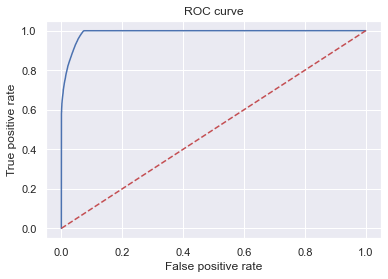

In [53]:
# We plot the false positive rate along the x-axis and the true positive rate along the y-axis
# This is definiton of ROC curve
plt.plot(fpr, tpr)
# Plot the diagonal which represents guessing
plt.plot(fpr, fpr, linestyle = '--', color = 'r')
# Axis labels and plot title
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')


In [54]:
AUROC = roc_auc_score(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test_proba'])

AUROC

0.9902683603051133

#### ***best threshold***

In [55]:
optimal_rate = tpr - fpr
optimal_idx = np.argmax(optimal_rate)
best_thresh = thresholds[optimal_idx]
print('Best Threshold=%f' % (best_thresh))

Best Threshold=0.846214


In [56]:

tr=0.896310
# if predicted prob > 0.896310 then predict 1 else predict 0
df_actual_predicted_probs['y_hat_test'] = np.where(df_actual_predicted_probs['y_hat_test_proba'] > tr, 1, 0)
conf_matrix(df_actual_predicted_probs['loan_data_targets_test'],df_actual_predicted_probs['y_hat_test'])

Predicted,0,1
Actual,,
0,52604,4130
1,742,393689


In [57]:
print ("accuracy = ", (52610+393668)/df_actual_predicted_probs.shape[0])

accuracy =  0.9891680427338113


### **Prob of default**

In [58]:
def compute_prob_of_default (array):
    coef = np.squeeze(logreg3.coef_)
    element_wise = np.sum(np.multiply(array,coef)) + logreg3.intercept_
    exponent = np.exp(element_wise)
    prob_of_default = (1/(1+exponent))
    prob_of_not_default = 1- prob_of_default
    return prob_of_default, prob_of_not_default

first_sample = np.array(inputs_test.loc[362514,:])
# print (first_sample)
compute_prob_of_default (first_sample)[0]

In [62]:
first_sample = np.array(inputs_test.loc[362514,:])
# print (first_sample)
compute_prob_of_default (first_sample)[0]

array([0.02170797])